# Project: AI-Driven Water Quality Prediction and Monitoring: A Unified Framework for Compliance Intelligence

#### DATE: Spring 2026
----

# Comprehensive Water Quality Modeling Notebook

This notebook includes:

1. **EDA before preprocessing**
2. **Preprocessing**
   - invalid value cleanup
   - hydrologic imputation decisions
   - outlier handling decisions
   - state-aware compliance flag creation
3. **EDA after preprocessing**
4. **Tabular forecasting track**
   - Linear Regression
   - Random Forest
   - XGBoost
5. **Deep learning forecasting track**
   - LSTM
6. **Driver analysis / explainability**
   - Multiple regression
   - Random Forest / XGBoost feature importance
   - SHAP plots
7. **Anomaly detection**
   - Autoencoder with threshold tuning
   - rule-based threshold baseline for comparison
8. **Compliance-risk classification**
   - Logistic Regression
   - Random Forest
   - XGBoost
9. **Formal hypothesis testing**
10. **Paper-ready tables and visualizations**

The final model set is intentionally restricted to: **Linear Regression, Random Forest, XGBoost, Logistic Regression, LSTM, and Autoencoder**. Optional experimental models such as TCN, LightGBM, CatBoost, TabNet, and weighted ensembles are excluded from the final analysis.


### Project Overview
This project is for building a multi-state water-quality dataset for modeling and research.

At a high level, it uses the EPA Water Quality Portal as the main source of truth, pulling stream monitoring data from CA, OR, WA, NV, and AZ for 2015-01-01 through 2024-12-31. It focuses on three measurements: pH, turbidity, and dissolved oxygen. The output is a cleaned, daily, site-level dataset that can be used for regression, explainability, anomaly detection, classification, and model comparison.

The main flow is:

Pull raw WQP measurements

src/wqp.py queries Water Quality Portal result and station APIs, normalizes state codes/dates, standardizes columns, and handles characteristic synonyms.

Build the core dataset

src/build_dataset.py drives the pipeline using config/config.multistate.yaml. It saves data/raw/wqp_long.csv, data/interim/wqp_wide.csv, station metadata, and final CSV/parquet outputs.

Add modeling features

src/features.py adds calendar features, lag features, rolling means, and a turbidity compliance flag where turbidity exceeds 5.0.

Optionally enrich with USGS data

src/enrich_with_usgs.py and src/usgs_enrichment.py add USGS daily values like discharge, water temperature, and gage height for sites whose IDs map to USGS stations.

The current generated dataset is already substantial: 144,849 rows across 2,236 monitoring sites, according to data/processed/extraction_summary.json. The enriched version preserves the same row count and adds USGS fields where available.

![image.png](attachment:image.png)

 ### Methodology for Data Collection, Processing, and Preparation"

The above shows the workflow that progresses from raw data acquisition to a fully processed dataset, ensuring consistency, scalability, and suitability for machine learning and deep learning applications.

# Important Modeling Note

For downstream modeling, use the following datasets:

- RQ1 forecasting: `df_A`
- RQ2 SHAP / driver analysis: `df_B`
- RQ3 anomaly detection: `df_A`
- RQ4 compliance classification: `df_B`
- RQ5 model comparison: `df_A`

Avoid using the full `df` or imputed `df_p` for RQ2/RQ4 unless it is explicitly derived from `df_B`.


# Data Dictionary for AI-Driven Water Quality Prediction and Monitoring Dataset

| Variable Name | Definition | Datatype | Allowed Values/Range | Missing Values Handling | Notes |
|---|---|---|---|---|---|
| `site_id` | Unique monitoring site identifier from WQP/USGS source records. | String / object | Valid station/site identifier | Rows retained; missing site IDs to be excluded from modeling because site/date grouping is required. | Used for grouping time-series observations and creating lag/rolling features. |
| `date` | Sampling or observation date at daily granularity. | Date / datetime | 2015-01-01 to 2024-12-31 | Invalid or missing dates to be removed. | Used for temporal ordering, trend analysis, lags, rolling means, and forecasting. |
| `turbidity` | Measure of water clarity and suspended particles in water. | Continuous numeric | ≥ 0 NTU; extreme values reviewed as potential events or outliers | Missing values retained during raw processing; rows with missing active target are excluded for target-specific modeling. | Primary target variable for RQ1/RQ5; also used in RQ3 anomaly detection and RQ4 operational-risk flagging. |
| `ph` | Measure of acidity or alkalinity. | Continuous numeric | 0–14; values outside range treated as chemically invalid | Invalid values removed or set to missing; missing values handled by target-specific exclusion or imputation. | Secondary target variable; dimensionless. |
| `dissolved_oxygen` | Oxygen concentration in water. | Continuous numeric | Typically ≥ 0 mg/L; unusually high values reviewed | Missing values retained initially; handled through target-specific exclusion or imputation. | Secondary target variable; supports multivariate modeling and anomaly detection. |
| `discharge` | Stream flow rate from USGS enrichment. | Continuous numeric | ≥ 0 ft³/s (cfs) | Missing values expected due to partial USGS coverage; used only in enriched Dataset B or imputed where appropriate. | Predictor for RQ2 and RQ4; important hydrologic driver. |
| `water_temp` | Water temperature from USGS enrichment. | Continuous numeric | Typically -5°C to 50°C; values checked for Celsius consistency | Missing values expected; used in enriched Dataset B or imputed where appropriate. | Predictor for RQ2/RQ4; thermal condition of water. |
| `gage_height` | Water level relative to a station datum. | Continuous numeric | Feet; plausible values depend on station | Missing values expected; treated as optional predictor. | Optional USGS predictor; lower coverage than discharge and temperature. |
| `site_name` | Descriptive name of monitoring location. | String / object | Valid station/site name | Retained for metadata; not used directly in numeric modeling. | Useful for interpretability, auditing, and reporting. |
| `site_type_name` | Type of monitoring site or waterbody context. | String / categorical | Examples: Stream, Canal, Reservoir, etc. | Retained; may be encoded if used as a categorical feature. | Supports site-context interpretation. |
| `huc8` | Hydrologic Unit Code identifying watershed region. | Numeric/string categorical | Valid HUC8 code | Missing values retained; may be excluded or encoded depending on modeling task. | Useful for watershed grouping and spatial context. |
| `state_code` | State identifier for monitoring location. | Integer / categorical | State codes for CA, OR, WA, NV, AZ | Missing values should be reviewed; rows retained if site/date/target are valid. | May be used for state-aware modeling or stratified analysis. |
| `county_code` | County identifier for monitoring location. | Integer / categorical | Valid county code | Missing values retained unless required for spatial analysis. | Metadata; generally excluded from baseline numeric models unless encoded. |
| `organization_name` | Organization responsible for data collection. | String / categorical | Valid agency/organization name | Retained for metadata and auditability. | Not used directly in core numeric modeling unless encoded. |
| `month` | Calendar month extracted from date. | Integer | 1–12 | Derived from date; missing only if date missing. | Time-based seasonality feature. |
| `quarter` | Calendar quarter extracted from date. | Integer | 1–4 | Derived from date; missing only if date missing. | Time-based seasonality feature. |
| `day_of_year` | Day number within calendar year. | Integer | 1–366 | Derived from date; missing only if date missing. | Captures annual seasonality. |
| `year` | Calendar year. | Integer | 2015–2024 | Derived from date; missing only if date missing. | Used for trend, split, and temporal validation. |
| `is_warm_season` | Binary indicator for warm-season months. | Integer / binary | 0 = not warm season; 1 = warm season | Derived from month; missing only if date missing. | Seasonality indicator for water-quality variation. |
| `turbidity_lag1` | Previous observed turbidity value for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected for first observation per site or gaps; may be imputed or rows dropped by model. | 1-step lag feature; supports temporal prediction. |
| `turbidity_lag3` | Turbidity value three prior observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected near site-series starts or gaps. | 3-step lag feature. |
| `turbidity_lag7` | Turbidity value seven prior observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected near site-series starts or gaps. | 7-step lag feature. |
| `ph_lag1` | Previous observed pH value for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 1-step pH lag feature. |
| `ph_lag3` | pH value three prior observations/time steps for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 3-step pH lag feature. |
| `ph_lag7` | pH value seven prior observations/time steps for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 7-step pH lag feature. |
| `dissolved_oxygen_lag1` | Previous observed dissolved oxygen value for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 1-step DO lag feature. |
| `dissolved_oxygen_lag3` | Dissolved oxygen value three prior observations/time steps for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 3-step DO lag feature. |
| `dissolved_oxygen_lag7` | Dissolved oxygen value seven prior observations/time steps for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 7-step DO lag feature. |
| `turbidity_rollmean7` | Rolling mean of turbidity over the prior 7 observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected until enough prior records exist. | Smooths short-term turbidity variability. |
| `turbidity_rollmean14` | Rolling mean of turbidity over the prior 14 observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected until enough prior records exist. | Captures broader local temporal context. |
| `ph_rollmean7` | Rolling mean of pH over prior 7 observations/time steps. | Continuous numeric | Same as pH, dimensionless | Missing expected until enough prior records exist. | Smooths short-term pH variability. |
| `ph_rollmean14` | Rolling mean of pH over prior 14 observations/time steps. | Continuous numeric | Same as pH, dimensionless | Missing expected until enough prior records exist. | Captures broader pH temporal context. |
| `dissolved_oxygen_rollmean7` | Rolling mean of dissolved oxygen over prior 7 observations/time steps. | Continuous numeric | Same as DO, mg/L | Missing expected until enough prior records exist. | Smooths short-term DO variability. |
| `dissolved_oxygen_rollmean14` | Rolling mean of dissolved oxygen over prior 14 observations/time steps. | Continuous numeric | Same as DO, mg/L | Missing expected until enough prior records exist. | Captures broader DO temporal context. |
| `compliance_flag` | Binary screening flag derived from turbidity threshold or high-turbidity condition. | Integer / binary | 0 = no flagged condition; 1 = flagged condition | Derived field; should not be used as predictor for same-row forecasting where leakage risk exists. | Screening/surrogate flag only; not formal regulatory compliance. |
| `compliance_flag_stateaware_next` | Future-oriented state-aware operational-risk flag. | Integer / binary | 0 = no next-period risk; 1 = next-period risk | Derived target for RQ4; rows with missing target excluded from classification training. | Target variable for RQ4; current-row compliance flags and contemporaneous target values should be excluded to reduce leakage. |
| `usgs_site_no` | USGS station number extracted for enrichment where available. | String / object | Valid USGS station number | Missing for non-USGS-backed WQP sites; rows retained in Dataset A. | Used to join USGS hydrologic variables into Dataset B. |

# Research Questions, Associated Problems, and Evaluation Focus

| Research Question (RQ) | Analytical Layer | Research Problem Addressed | Evaluation Focus |
|---|---|---|---|
| RQ1 | Prediction | Can next-period turbidity, pH, and dissolved oxygen be forecast accurately using ML and DL models? | RMSE, MAE, R²; practical RMSE reduction versus baseline |
| RQ2 | Explainability | Which hydrologic, temporal, and lagged factors most influence short-term water quality? | Feature importance, SHAP, p-values |
| RQ3 | Anomaly Detection | Can unsupervised models detect abnormal water-quality behavior better than threshold rules? | Precision, Recall, F1, ROC-AUC |
| RQ4 | Compliance Classification | Can historical signals predict future state-aware compliance risk? | Precision, Recall, F1, ROC-AUC |
| RQ5 | Model Comparison | Do ML/DL methods materially outperform statistical baselines? | Comparative RMSE, MAE, statistical and practical significance |

**Note.** Table 1 shows that the project is designed as an integrated analytical system rather than a single-model exercise. Forecasting, explainability, anomaly detection, classification, and comparative evaluation are treated as linked but distinct problems.

#### Prepare the notebook environment for the full water-quality modeling workflow.

Load packages for:
* Data handling using pandas and numpy
* Visualization using matplotlib and seaborn
* Regression and classification using scikit-learn
* Statistical analysis using statsmodels and scipy
* XGBoost modeling
* SHAP explainability
* Deep learning using TensorFlow/Keras, including LSTM and Autoencoder models


In [1]:
# Optional install if running in a fresh environment:
# !pip -q install xgboost shap statsmodels

# =========================================================
# Imports and Reproducibility Settings
# =========================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

# Reproducibility seed
SEED = 34
os.environ["PYTHONHASHSEED"] = str(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(SEED)
np.random.seed(SEED)

from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import statsmodels.api as sm

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    tf.keras.utils.set_random_seed(SEED)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping

except Exception as e:
    print("TensorFlow import or deterministic setup warning:", e)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# Output folders for paper-ready artifacts
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

DATA_PATH = "/content/drive/MyDrive/WQP Modelling/final_dataset_enriched.parquet"

## Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Raw shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())


Raw shape: (144849, 38)
Columns: 38


,site_id,date,dissolved_oxygen,ph,turbidity,site_name,site_type_name,huc8,state_code,county_code,organization_name,month,quarter,day_of_year,year,is_warm_season,ph_lag1,ph_lag3,ph_lag7,turbidity_lag1,turbidity_lag3,turbidity_lag7,dissolved_oxygen_lag1,dissolved_oxygen_lag3,dissolved_oxygen_lag7,ph_rollmean7,ph_rollmean14,turbidity_rollmean7,turbidity_rollmean14,dissolved_oxygen_rollmean7,dissolved_oxygen_rollmean14,compliance_flag,usgs_site_no_x,usgs_site_no_y,discharge,gage_height,water_temp,usgs_site_no
0,1119USBR_WQX-CBP008,2015-02-10,10.7,7.9,1.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,2,1,41,2015,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,None,NaN,NaN,NaN,None
1,1119USBR_WQX-CBP008,2015-04-21,10.7,7.2,3.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,4,2,111,2015,1,7.9,NaN,NaN,1.0,NaN,NaN,10.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,None,NaN,NaN,NaN,None
2,1119USBR_WQX-CBP008,2015-06-10,8.9,7.6,8.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,6,2,161,2015,1,7.2,NaN,NaN,3.0,NaN,NaN,10.7,NaN,NaN,7.566667,NaN,4.0,NaN,10.100,NaN,1,None,None,NaN,NaN,NaN,None
3,1119USBR_WQX-CBP008,2015-07-28,9.2,7.4,2.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,7,3,209,2015,1,7.6,7.9,NaN,8.0,1.0,NaN,8.9,10.7,NaN,7.525000,NaN,3.5,NaN,9.875,NaN,0,None,None,NaN,NaN,NaN,None
4,1119USBR_WQX-CBP008,2015-10-19,10.2,7.2,NaN,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,10,4,292,2015,0,7.4,7.2,NaN,2.0,3.0,NaN,9.2,10.7,NaN,7.460000,NaN,3.5,NaN,9.940,NaN,0,None,None,NaN,NaN,NaN,None


# Required Pre-Modeling Fixes: Physical Validity, Track A/B, and RQ Routing

This section applies the essential methodological fixes before modeling:

1. Removes physically invalid target values.
2. Caps extreme target outliers using IQR-based winsorization.
3. Creates Track A and Track B before any hydrologic imputation.
4. Routes each research question to the correct dataset.
5. Initializes storage for prediction-level outputs required for rigorous hypothesis testing.

Track B is created using original hydrologic availability flags so that RQ2 and RQ4 use rows with real measured hydrologic data rather than values created by imputation.


In [4]:
# =========================================================
# ESSENTIAL PRE-MODELING FIXES
# Physical validity -> Outlier capping -> Track A/B -> RQ routing
# =========================================================

import numpy as np
import pandas as pd
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 0. Keep a copy of the originally loaded dataframe
# ---------------------------------------------------------
# IMPORTANT:
# This cell should be run after the dataset is loaded but before modeling and before hydrologic imputation.
# If df_raw does not exist yet, preserve df as the raw/base dataframe.

if "df" not in globals():
    raise NameError("Expected a dataframe named df to exist before this cell. Please run the dataset loading cell first.")

if "df_raw" not in globals():
    df_raw = df.copy()
    print("Created df_raw from current df.")

df = df_raw.copy()

# ---------------------------------------------------------
# 1. Physical validity filtering BEFORE modeling
# ---------------------------------------------------------
target_cols = ["turbidity", "ph", "dissolved_oxygen"]

for col in target_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        raise ValueError(f"Missing required target column: {col}")

initial_rows = len(df)

# pH valid range: 0 to 14
df = df[
    (df["ph"].isna()) |
    ((df["ph"] >= 0) & (df["ph"] <= 14))
].copy()

# Dissolved oxygen valid range: 0 to 25 mg/L for modeling stability
df = df[
    (df["dissolved_oxygen"].isna()) |
    ((df["dissolved_oxygen"] >= 0) & (df["dissolved_oxygen"] <= 25))
].copy()

# Turbidity cannot be negative
df = df[
    (df["turbidity"].isna()) |
    (df["turbidity"] >= 0)
].copy()

valid_rows = len(df)

print("=" * 80)
print("PHYSICAL VALIDITY FILTERING")
print("=" * 80)
print(f"Initial rows: {initial_rows:,}")
print(f"Rows after physical validity filtering: {valid_rows:,}")
print(f"Rows removed: {initial_rows - valid_rows:,}")

# ---------------------------------------------------------
# 2. IQR outlier capping BEFORE modeling
# ---------------------------------------------------------
outlier_log = []

for col in target_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    if col in ["turbidity", "dissolved_oxygen"]:
        lower = max(lower, 0)

    if col == "ph":
        lower = max(lower, 0)
        upper = min(upper, 14)

    if col == "dissolved_oxygen":
        upper = min(upper, 25)

    n_low = int((df[col] < lower).sum())
    n_high = int((df[col] > upper).sum())

    df[col] = df[col].clip(lower=lower, upper=upper)

    outlier_log.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_cap": lower,
        "upper_cap": upper,
        "values_capped_low": n_low,
        "values_capped_high": n_high,
        "total_values_capped": n_low + n_high
    })

outlier_log_df = pd.DataFrame(outlier_log)
display(outlier_log_df)
outlier_log_df.to_csv("outputs/tables/outlier_capping_log.csv", index=False)

print("\nPost-cleaning target summary:")
display(df[target_cols].describe().T)

# ---------------------------------------------------------
# 3. Proper Track A / Track B creation BEFORE imputation
# ---------------------------------------------------------
# Preserve original hydrology availability flags BEFORE any imputation.
for col in ["discharge", "water_temp", "gage_height"]:
    if col not in df.columns:
        df[col] = np.nan

df["orig_has_discharge"] = df["discharge"].notna()
df["orig_has_water_temp"] = df["water_temp"].notna()
df["orig_has_gage_height"] = df["gage_height"].notna()
df["orig_hydro_count"] = df[["orig_has_discharge", "orig_has_water_temp", "orig_has_gage_height"]].sum(axis=1)

# Track A: full cleaned dataset
df_A = df.copy()

# Track B: hydrologically complete measured subset
# Recommended strict rule: original discharge AND original water_temp present.
# Gage height remains optional due to high missingness.
df_B = df[
    (df["orig_has_discharge"]) &
    (df["orig_has_water_temp"])
].copy()

print("\n" + "=" * 80)
print("TRACK A / TRACK B SUMMARY")
print("=" * 80)
print("Track A shape:", df_A.shape)
print("Track B shape:", df_B.shape)

print("\nTrack B hydrologic missingness after filtering:")
display(df_B[["discharge", "water_temp", "gage_height"]].isna().mean().mul(100).round(2))

track_summary = pd.DataFrame([
    {
        "Track": "Track A",
        "Dataset Object": "df_A",
        "Rows": df_A.shape[0],
        "Columns": df_A.shape[1],
        "Purpose": "RQ1/RQ3/RQ5: forecasting, anomaly detection, model comparison",
        "Hydrologic Requirement": "None"
    },
    {
        "Track": "Track B",
        "Dataset Object": "df_B",
        "Rows": df_B.shape[0],
        "Columns": df_B.shape[1],
        "Purpose": "RQ2/RQ4: hydrologic driver analysis and compliance-risk classification",
        "Hydrologic Requirement": "Original discharge AND original water_temp required"
    }
])

display(track_summary)
track_summary.to_csv("outputs/tables/track_a_b_summary.csv", index=False)

# ---------------------------------------------------------
# 4. Use Track A/B correctly by RQ
# ---------------------------------------------------------
RQ_DATASETS = {
    "RQ1": df_A,
    "RQ2": df_B,
    "RQ3": df_A,
    "RQ4": df_B,
    "RQ5": df_A
}

rq_dataset_map = pd.DataFrame([
    {"RQ": "RQ1", "Dataset": "df_A / Track A", "Reason": "Maximize forecasting sample size"},
    {"RQ": "RQ2", "Dataset": "df_B / Track B", "Reason": "Use originally observed hydrologic drivers"},
    {"RQ": "RQ3", "Dataset": "df_A / Track A", "Reason": "Maximize anomaly coverage"},
    {"RQ": "RQ4", "Dataset": "df_B / Track B", "Reason": "Compliance modeling with real hydrologic predictors"},
    {"RQ": "RQ5", "Dataset": "df_A / Track A", "Reason": "Maximize model-comparison stability"}
])

display(rq_dataset_map)
rq_dataset_map.to_csv("outputs/tables/rq_dataset_mapping.csv", index=False)

print("\nRQ dataset routing confirmed:")
for rq, data_obj in RQ_DATASETS.items():
    print(f"{rq}: {data_obj.shape}")

# ---------------------------------------------------------
# 5. Initialize prediction-level storage for rigorous hypothesis testing
# ---------------------------------------------------------
# Store y_true, y_pred, errors, and squared errors inside model loops.
# This enables paired t-test and Wilcoxon testing.

results_store = {}

def save_regression_predictions(target, model_name, y_true, y_pred):
    """Save prediction-level outputs for rigorous paired statistical testing."""
    global results_store

    if target not in results_store:
        results_store[target] = {}

    y_true_arr = np.asarray(y_true).reshape(-1)
    y_pred_arr = np.asarray(y_pred).reshape(-1)

    results_store[target][model_name] = {
        "y_true": y_true_arr,
        "y_pred": y_pred_arr,
        "errors": np.abs(y_true_arr - y_pred_arr),
        "sq_errors": (y_true_arr - y_pred_arr) ** 2
    }

def save_classification_predictions(task_name, model_name, y_true, y_pred, y_proba=None):
    """Save classification-level outputs for McNemar/ROC/F1 comparison."""
    global results_store

    if task_name not in results_store:
        results_store[task_name] = {}

    results_store[task_name][model_name] = {
        "y_true": np.asarray(y_true).reshape(-1),
        "y_pred": np.asarray(y_pred).reshape(-1),
        "y_proba": None if y_proba is None else np.asarray(y_proba).reshape(-1)
    }

print("\nInitialized results_store and helper functions:")
print("- save_regression_predictions(target, model_name, y_true, y_pred)")
print("- save_classification_predictions(task_name, model_name, y_true, y_pred, y_proba=None)")


Created df_raw from current df.
PHYSICAL VALIDITY FILTERING
Initial rows: 144,849
Rows after physical validity filtering: 132,254
Rows removed: 12,595


,variable,q1,q3,iqr,lower_cap,upper_cap,values_capped_low,values_capped_high,total_values_capped
0,turbidity,1.400000,9.000000,7.600000,0.000000,20.400000,0,11233,11233
1,ph,7.148194,7.973846,0.825652,5.909717,9.212324,716,528,1244
2,dissolved_oxygen,8.330000,11.020000,2.690000,4.295000,15.055000,2682,429,3111



Post-cleaning target summary:


,count,mean,std,min,25%,50%,75%,max
turbidity,94738.0,6.338583,6.661563,0.000000,1.400000,3.400000,9.000000,20.400000
ph,87281.0,7.548784,0.596403,5.909717,7.148194,7.550000,7.973846,9.212324
dissolved_oxygen,90178.0,9.566665,2.085804,4.295000,8.330000,9.743018,11.020000,15.055000



TRACK A / TRACK B SUMMARY
Track A shape: (132254, 42)
Track B shape: (4015, 42)

Track B hydrologic missingness after filtering:


,0
discharge,0.00
water_temp,0.00
gage_height,95.17


,Track,Dataset Object,Rows,Columns,Purpose,Hydrologic Requirement
0,Track A,df_A,132254,42,"RQ1/RQ3/RQ5: forecasting, anomaly detection, m...",None
1,Track B,df_B,4015,42,RQ2/RQ4: hydrologic driver analysis and compli...,Original discharge AND original water_temp req...


,RQ,Dataset,Reason
0,RQ1,df_A / Track A,Maximize forecasting sample size
1,RQ2,df_B / Track B,Use originally observed hydrologic drivers
2,RQ3,df_A / Track A,Maximize anomaly coverage
3,RQ4,df_B / Track B,Compliance modeling with real hydrologic predi...
4,RQ5,df_A / Track A,Maximize model-comparison stability



RQ dataset routing confirmed:
RQ1: (132254, 42)
RQ2: (4015, 42)
RQ3: (132254, 42)
RQ4: (4015, 42)
RQ5: (132254, 42)

Initialized results_store and helper functions:
- save_regression_predictions(target, model_name, y_true, y_pred)
- save_classification_predictions(task_name, model_name, y_true, y_pred, y_proba=None)


## Preprocessing controls

The three configuration settings for the water-quality modeling pipeline.
IMPUTE_HYDROLOGY = True - missing hydrologic variables such as discharge, gage_height, and water_temp will be imputed instead of being left missing or removed immediately.

OUTLIER_MODE = "cap" - extreme values will be capped or winsorized rather than removed. For example, unusually high turbidity or discharge values may be limited to an upper threshold to reduce model instability while still retaining the observation.

STATE_AWARE_FLAG = True - the compliance-risk flag will account for state-specific or state-aware logic rather than using one generic threshold for all locations.


In [5]:
    IMPUTE_HYDROLOGY = True
    OUTLIER_MODE = "cap"   # choose: "cap", "remove", "none"
    STATE_AWARE_FLAG = True

    print("IMPUTE_HYDROLOGY =", IMPUTE_HYDROLOGY)
    print("OUTLIER_MODE =", OUTLIER_MODE)
    print("STATE_AWARE_FLAG =", STATE_AWARE_FLAG)


IMPUTE_HYDROLOGY = True
OUTLIER_MODE = cap
STATE_AWARE_FLAG = True


## EDA before preprocessing

The initial exploratory data analysis on the raw water-quality dataset.


Missing % by column


,0
gage_height,99.441983
water_temp,96.165711
discharge,95.110167
usgs_site_no_y,94.310191
usgs_site_no_x,94.233067
usgs_site_no,90.537904
ph_lag7,43.192644
ph_rollmean14,41.744673
dissolved_oxygen_lag7,39.675171
dissolved_oxygen_rollmean14,38.007924


,count,mean,std,min,25%,50%,75%,max
turbidity,94738.0,6.338583,6.661563,0.000000,1.400000,3.400000,9.000000,20.400000
dissolved_oxygen,90178.0,9.566665,2.085804,4.295000,8.330000,9.743018,11.020000,15.055000
ph,87281.0,7.548784,0.596403,5.909717,7.148194,7.550000,7.973846,9.212324


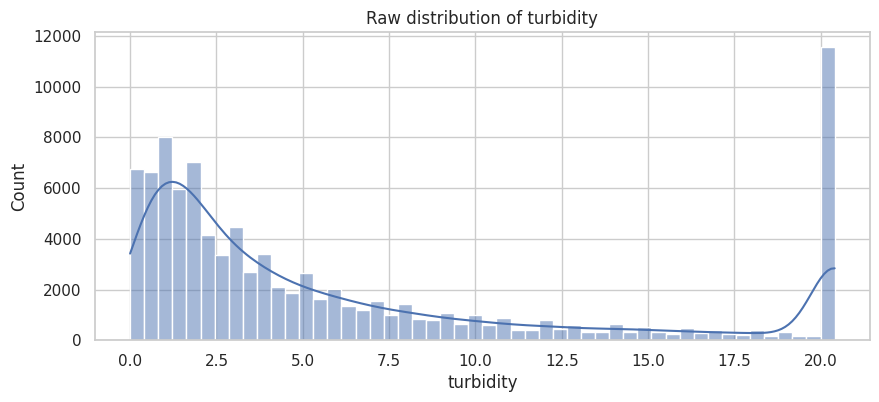

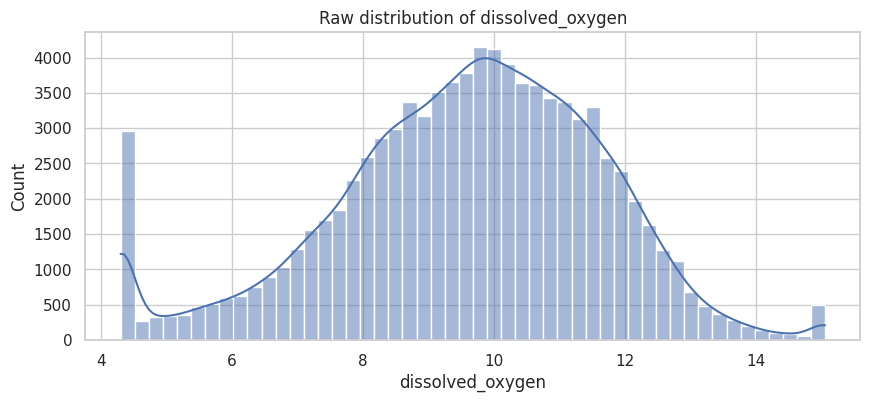

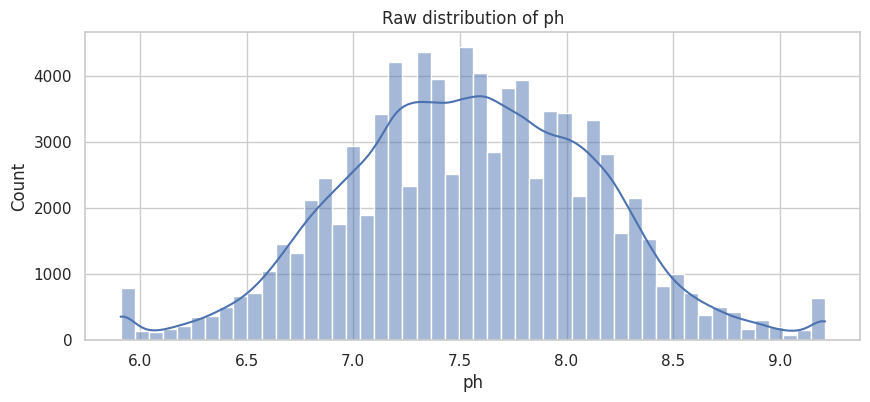

Raw ph vs turbidity correlation: -0.0375


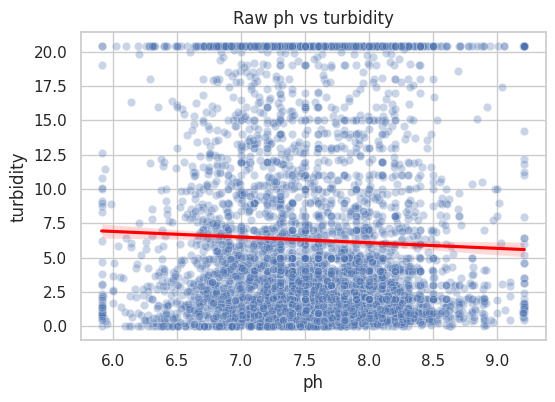

Raw dissolved_oxygen vs turbidity correlation: 0.0208


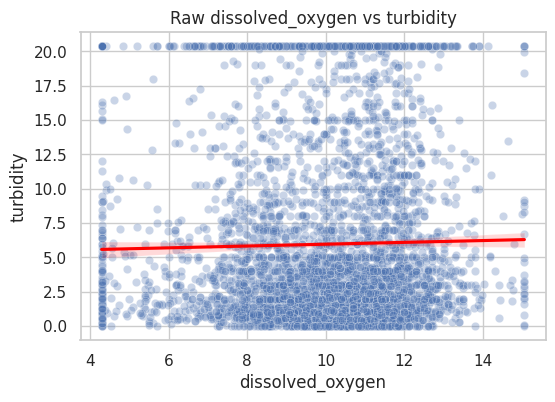

Raw ph vs dissolved_oxygen correlation: 0.0014


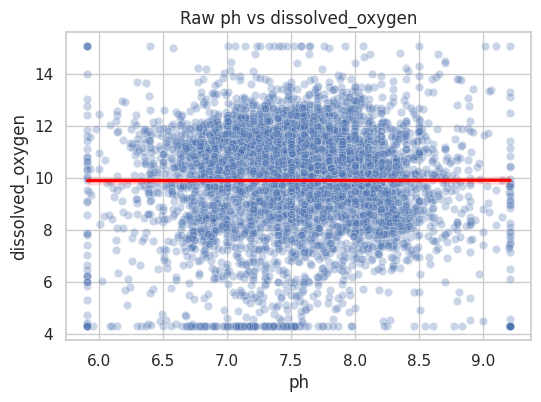

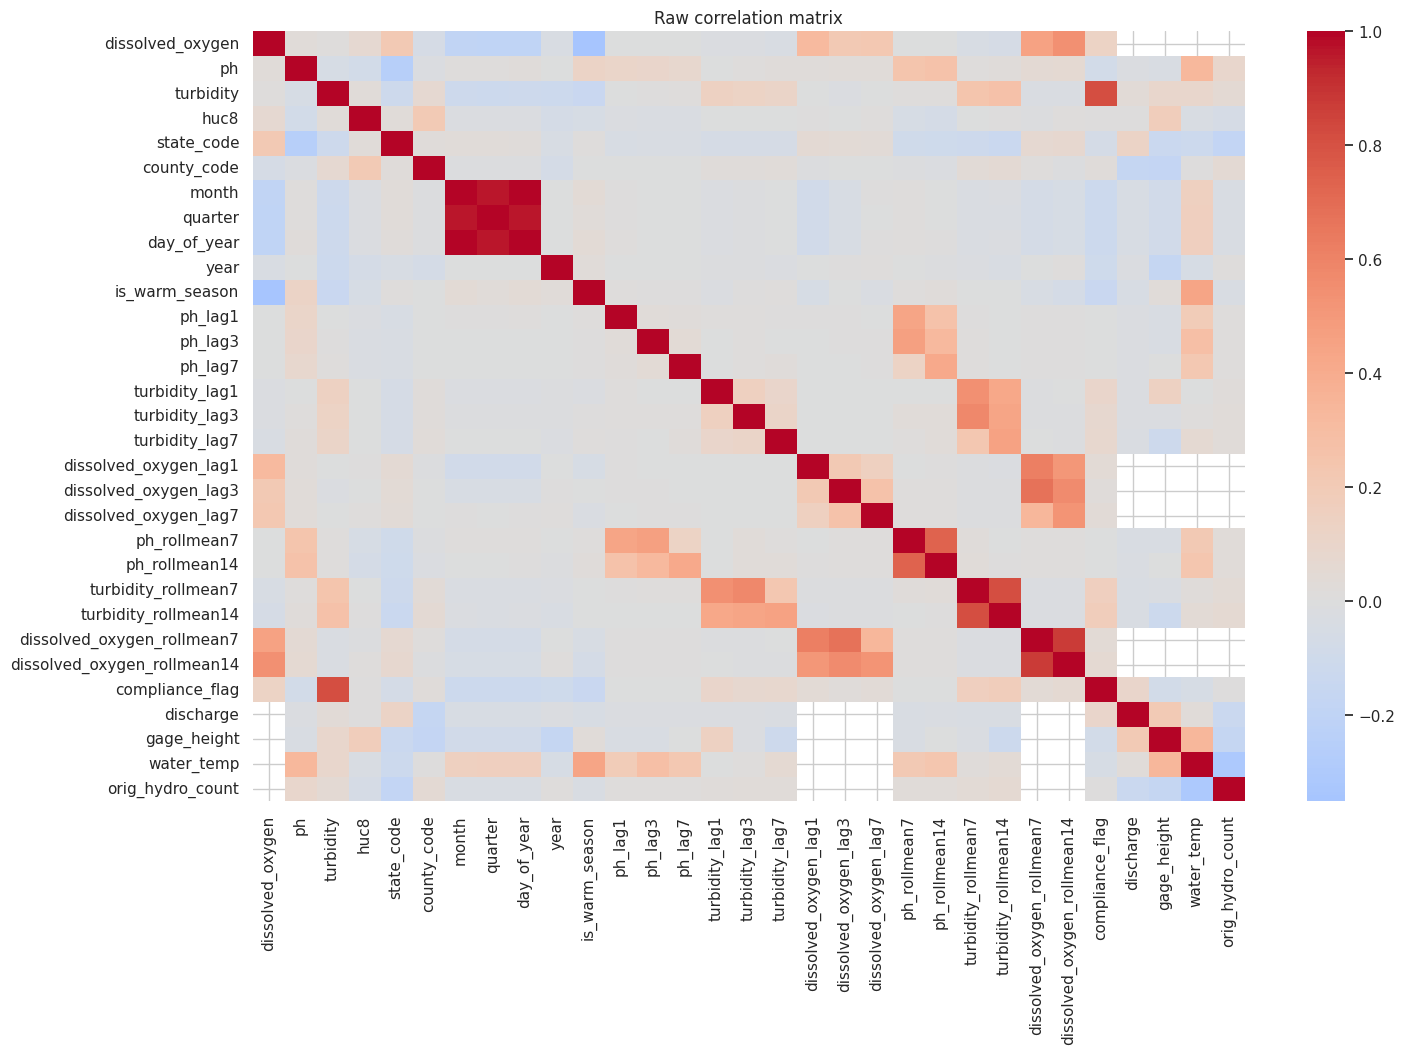

In [6]:
# Calculates the percentage of missing values in each column, sorts them from highest to lowest, and displays the top 50 columns with the most missing data.

print("Missing % by column")
display((df.isna().mean() * 100).sort_values(ascending=False).head(50))

# Select the main water-quality variables and produces summary statistics such as count, mean, standard deviation, minimum, quartiles, and maximum.
core_cols = [c for c in ["turbidity", "dissolved_oxygen", "ph"] if c in df.columns]
display(df[core_cols].describe().T)

for col in core_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f"Raw distribution of {col}")
    plt.show()

# Plot the raw distribution of each key variable. This helps identify skewness, extreme values, unusual ranges, and whether variables may require transformation or outlier treatment
# scatterplot to compare key variable pairs such as pH versus turbidity and dissolved oxygen versus turbidity. Pint their raw correlations and adds a regression line to visually assess linear relationships.
sample = df.sample(min(len(df), 10000), random_state=42)
for x, y in [("ph", "turbidity"), ("dissolved_oxygen", "turbidity"), ("ph", "dissolved_oxygen")]:
    if x in df.columns and y in df.columns:
        temp = sample[[x, y]].dropna()
        print(f"Raw {x} vs {y} correlation:", round(temp[x].corr(temp[y]), 4))
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=temp, x=x, y=y, alpha=0.3)
        sns.regplot(data=temp, x=x, y=y, scatter=False, color="red")
        plt.title(f"Raw {x} vs {y}")
        plt.show()

num_df_raw = df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
plt.figure(figsize=(16,10))
sns.heatmap(num_df_raw.corr(), cmap="coolwarm", center=0)
plt.title("Raw correlation matrix")
plt.show()


#### NOTE:

Before preprocessing, exploratory data analysis (EDA) revealed substantial missingness and extreme variability across several variables. Hydrologic variables such as gage height (99.49% missing), water temperature (96.50%), and discharge (95.54%) exhibited the highest missing rates due to limited overlap between WQP and USGS monitoring coverage. Missingness also increased significantly after temporal feature engineering, with 7-day lag and 14-day rolling features showing missing rates between approximately 33% and 40%, reflecting the sequential nature of time-series calculations.

Descriptive statistics further showed that turbidity exhibited the greatest variability and strongest right-skewness (mean = 21.31 NTU; max = 24,800 NTU), indicating the presence of extreme event-driven observations. Dissolved oxygen and pH also contained implausible negative and extreme values, suggesting potential sensor, reporting, or measurement anomalies. These findings justified subsequent preprocessing steps including invalid-value filtering, outlier handling, selective imputation, and the use of separate dataset tracks for hydrologically enriched analyses (see Table 5).

Looking at the correlation matrix, we can see that the strongest correlations occur between each target variable and its own lagged and rolling features, confirming strong temporal dependence in the dataset. pH and dissolved oxygen exhibit more stable temporal structure than turbidity, while hydrologic variables show weaker raw linear relationships, suggesting that their influence may be nonlinear or site-specific.

## 4. Data Preprocessing



In [7]:
df_p = df.copy()

# ---- state code mapping ----
state_code_map = {
    4: "AZ",
    6: "CA",
    32: "NV",
    41: "OR",
    53: "WA"
}

if "state_abbr" not in df_p.columns and "state_code" in df_p.columns:
    df_p["state_abbr"] = df_p["state_code"].astype(int).map(state_code_map)

# ---- invalid value cleanup ----
if "ph" in df_p.columns:
    df_p.loc[(df_p["ph"] < 0) | (df_p["ph"] > 14), "ph"] = np.nan

if "dissolved_oxygen" in df_p.columns:
    df_p.loc[df_p["dissolved_oxygen"] < 0, "dissolved_oxygen"] = np.nan

if "turbidity" in df_p.columns:
    df_p.loc[df_p["turbidity"] < 0, "turbidity"] = np.nan

# ---- time features ----
df_p["month"] = df_p["date"].dt.month
df_p["quarter"] = df_p["date"].dt.quarter
df_p["day_of_year"] = df_p["date"].dt.dayofyear
df_p["year"] = df_p["date"].dt.year

if "is_warm_season" not in df_p.columns:
    df_p["is_warm_season"] = df_p["month"].isin([5,6,7,8,9]).astype(int)

SITE_COL = "site_id"
SITE_BG_COL = "usgs_site_no" if "usgs_site_no" in df_p.columns else SITE_COL

# ---- optional hydrologic imputation ----
hydro_cols = [c for c in ["gage_height", "discharge", "water_temp"] if c in df_p.columns]
if IMPUTE_HYDROLOGY and len(hydro_cols) > 0:
    for col in hydro_cols:
        site_month_mean = df_p.groupby([SITE_COL, "month"])[col].transform("mean")
        df_p[col] = df_p[col].fillna(site_month_mean)

        site_mean = df_p.groupby(SITE_COL)[col].transform("mean")
        df_p[col] = df_p[col].fillna(site_mean)

        global_mean = df_p[col].mean()
        df_p[col] = df_p[col].fillna(global_mean)

# ---- state-aware screening compliance flag ----
if STATE_AWARE_FLAG and "turbidity" in df_p.columns and "state_abbr" in df_p.columns:
    df_p["background_turbidity_est"] = (
        df_p.groupby(SITE_BG_COL)["turbidity"]
        .transform(lambda s: s.shift(1).rolling(window=30, min_periods=5).median())
    )

    site_bg = df_p.groupby(SITE_BG_COL)["turbidity"].transform("median")
    df_p["background_turbidity_est"] = df_p["background_turbidity_est"].fillna(site_bg)
    df_p["background_turbidity_est"] = df_p["background_turbidity_est"].fillna(df_p["turbidity"].median())

    df_p["compliance_flag_stateaware"] = pd.Series(np.nan, index=df_p.index, dtype="float")
    df_p["compliance_rule_used"] = None

    mask_or = df_p["state_abbr"] == "OR"
    if mask_or.any():
        turb = df_p.loc[mask_or, "turbidity"]
        bg = df_p.loc[mask_or, "background_turbidity_est"]
        df_p.loc[mask_or, "compliance_flag_stateaware"] = (turb > bg * 1.10).astype(int)
        df_p.loc[mask_or, "compliance_rule_used"] = "OR screening: >10% above background"

    mask_wa = df_p["state_abbr"] == "WA"
    if mask_wa.any():
        turb = df_p.loc[mask_wa, "turbidity"]
        bg = df_p.loc[mask_wa, "background_turbidity_est"]
        wa_flag = (
            ((bg <= 50) & (turb > bg + 5)) |
            ((bg > 50) & (turb > bg * 1.10))
        ).astype(int)
        df_p.loc[mask_wa, "compliance_flag_stateaware"] = wa_flag
        df_p.loc[mask_wa, "compliance_rule_used"] = "WA screening: +5 NTU over bg if <=50 else +10%"

    mask_ca = df_p["state_abbr"] == "CA"
    if mask_ca.any():
        turb = df_p.loc[mask_ca, "turbidity"]
        bg = df_p.loc[mask_ca, "background_turbidity_est"]
        df_p.loc[mask_ca, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_ca, "compliance_rule_used"] = "CA screening fallback: >20% above background"

    mask_az = df_p["state_abbr"] == "AZ"
    if mask_az.any():
        turb = df_p.loc[mask_az, "turbidity"]
        bg = df_p.loc[mask_az, "background_turbidity_est"]
        df_p.loc[mask_az, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_az, "compliance_rule_used"] = "AZ screening fallback: >20% above background"

    mask_nv = df_p["state_abbr"] == "NV"
    if mask_nv.any():
        turb = df_p.loc[mask_nv, "turbidity"]
        bg = df_p.loc[mask_nv, "background_turbidity_est"]
        df_p.loc[mask_nv, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_nv, "compliance_rule_used"] = "NV screening fallback: >20% above background"

    df_p["compliance_flag_stateaware"] = df_p["compliance_flag_stateaware"].astype("Int64")

# ---- optional outlier handling ----
outlier_cols = [c for c in [
    "turbidity", "dissolved_oxygen", "ph",
    "gage_height", "discharge", "water_temp"
] if c in df_p.columns]

if OUTLIER_MODE == "cap":
    for col in outlier_cols:
        s = df_p[col].dropna()
        if len(s) > 0:
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df_p[col] = df_p[col].clip(lower=lower, upper=upper)

elif OUTLIER_MODE == "remove":
    for col in outlier_cols:
        s = df_p[col].dropna()
        if len(s) > 0:
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df_p = df_p[
                df_p[col].isna() |
                ((df_p[col] >= lower) & (df_p[col] <= upper))
            ].copy()

# ---- final strict sort before any splitting ----
sort_cols = [c for c in ["state_abbr", SITE_COL, "date"] if c in df_p.columns]
df_p = df_p.sort_values(sort_cols).reset_index(drop=True)

print("Processed shape:", df_p.shape)
print("Sort columns used:", sort_cols)

if "compliance_flag_stateaware" in df_p.columns:
    print("\nState-aware flag counts")
    print(df_p["compliance_flag_stateaware"].value_counts(dropna=False))

display(df_p.head())


Processed shape: (132254, 46)
Sort columns used: ['state_abbr', 'site_id', 'date']

State-aware flag counts
compliance_flag_stateaware
0    93448
1    38806
Name: count, dtype: Int64


,site_id,date,dissolved_oxygen,ph,turbidity,site_name,site_type_name,huc8,state_code,county_code,organization_name,month,quarter,day_of_year,year,is_warm_season,ph_lag1,ph_lag3,ph_lag7,turbidity_lag1,turbidity_lag3,turbidity_lag7,dissolved_oxygen_lag1,dissolved_oxygen_lag3,dissolved_oxygen_lag7,ph_rollmean7,ph_rollmean14,turbidity_rollmean7,turbidity_rollmean14,dissolved_oxygen_rollmean7,dissolved_oxygen_rollmean14,compliance_flag,usgs_site_no_x,usgs_site_no_y,discharge,gage_height,water_temp,usgs_site_no,orig_has_discharge,orig_has_water_temp,orig_has_gage_height,orig_hydro_count,state_abbr,background_turbidity_est,compliance_flag_stateaware,compliance_rule_used
0,AK-CHIN_WQX-LTP-20,2015-03-30,8.57,8.72,11.20,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),3,1,89,2015,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,None,None,5600.210001,4.125857,11.741277,None,False,False,False,0,AZ,3.4,1,AZ screening fallback: >20% above background
1,AK-CHIN_WQX-LTP-20,2015-09-23,6.91,8.28,6.41,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),9,3,266,2015,1,8.72,NaN,NaN,11.20,NaN,NaN,8.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,None,None,5600.210001,4.125857,11.741277,None,False,False,False,0,AZ,3.4,1,AZ screening fallback: >20% above background
2,AK-CHIN_WQX-LTP-20,2015-12-05,8.10,8.33,8.23,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),12,4,339,2015,0,8.28,NaN,NaN,6.41,NaN,NaN,6.91,NaN,NaN,8.443333,NaN,8.613333,NaN,7.860,NaN,1,None,None,5600.210001,4.125857,11.741277,None,False,False,False,0,AZ,3.4,1,AZ screening fallback: >20% above background
3,AK-CHIN_WQX-LTP-20,2016-02-29,10.26,8.07,4.11,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),2,1,60,2016,0,8.33,8.72,NaN,8.23,11.20,NaN,8.10,8.57,NaN,8.350000,NaN,7.487500,NaN,8.460,NaN,0,None,None,5600.210001,4.125857,11.741277,None,False,False,False,0,AZ,3.4,1,AZ screening fallback: >20% above background
4,AK-CHIN_WQX-LTP-20,2016-04-27,6.85,8.98,6.70,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),4,2,118,2016,1,8.07,8.28,NaN,4.11,6.41,NaN,10.26,6.91,NaN,8.476000,NaN,7.330000,NaN,8.138,NaN,1,None,None,5600.210001,4.125857,11.741277,None,False,False,False,0,AZ,3.4,1,AZ screening fallback: >20% above background


| Issue | Variables Affected | Detection Method | Treatment Applied | Rationale |
|---|---|---|---|---|
| Missing values from temporal feature engineering | Lag features, rolling means | Null-count and percentage audit after feature creation | Retained initially; rows excluded selectively depending on modeling task | Lag and rolling features inherently require prior observations and therefore create structural missingness in time-series data |
| Missing hydrologic data | Discharge, gage height, water temperature | Null-count analysis after WQP–USGS merge | Optional site-month mean imputation; incomplete rows retained in Dataset A | Not all WQP stations had corresponding USGS enrichment data |
| Missing target observations | Turbidity, pH, dissolved oxygen | Missing-value audit | Rows excluded for target-specific supervised modeling | Predictive models require valid target labels |
| Invalid pH values | pH | Range validation (outside 0–14) | Invalid observations removed or converted to missing | Values outside the chemically valid range are physically implausible |
| Outliers | Turbidity, dissolved oxygen, pH | IQR-based outlier screening | Outliers retained by default; optional capping applied during sensitivity testing | Environmental spikes may represent genuine contamination or storm-driven events |
| Extreme hydrologic values | Discharge, gage height, water temperature | Quantile/IQR audit | Optional capping/winsorization | Reduces instability caused by extreme hydrologic measurements |
| Duplicate site-day records | All variables | Duplicate detection using site/date combinations | Aggregated using daily mean values | Ensures one observation per site-day for temporal modeling |
| Inconsistent parameter naming | Water-quality parameters | Parameter mapping audit | Standardized into canonical variable names | Required for consistent merging and feature engineering |
| Temporal inconsistencies | Date/time variables | Datetime parsing and ordering checks | Standardized datetime formats and chronological sorting | Necessary for lag, rolling-window, and sequence models |
| Leakage risk in compliance modeling | Compliance flags and contemporaneous targets | Feature-selection review | Current-row compliance variables excluded from predictors | Reduces target leakage in RQ4 classification models |

## EDA after preprocessing (after data prep-processing to address the issues mentioned ealier)

Missing % after preprocessing


,0
usgs_site_no_y,94.310191
usgs_site_no_x,94.233067
usgs_site_no,90.537904
ph_lag7,43.192644
ph_rollmean14,41.744673
dissolved_oxygen_lag7,39.675171
dissolved_oxygen_rollmean14,38.007924
ph_lag3,37.923239
turbidity_lag7,36.581124
ph_rollmean7,35.776612


,count,mean,std,min,25%,50%,75%,max
turbidity,94738.0,6.338583,6.661563,0.000000,1.400000,3.400000,9.000000,20.400000
dissolved_oxygen,90178.0,9.566665,2.085804,4.295000,8.330000,9.743018,11.020000,15.055000
ph,87281.0,7.548784,0.596403,5.909717,7.148194,7.550000,7.973846,9.212324


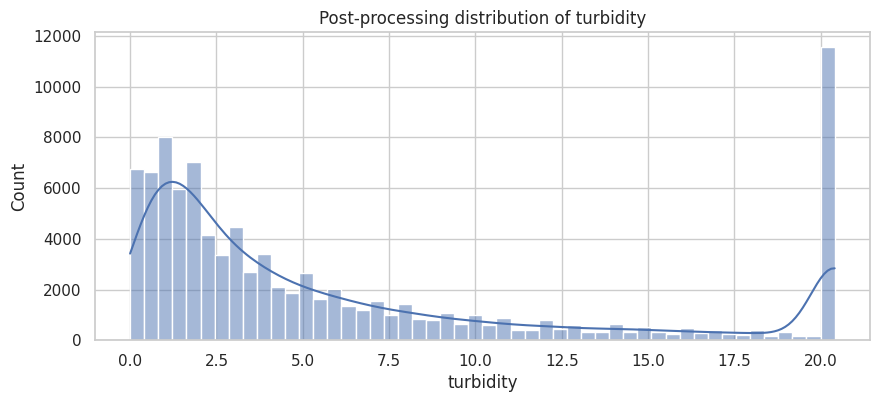

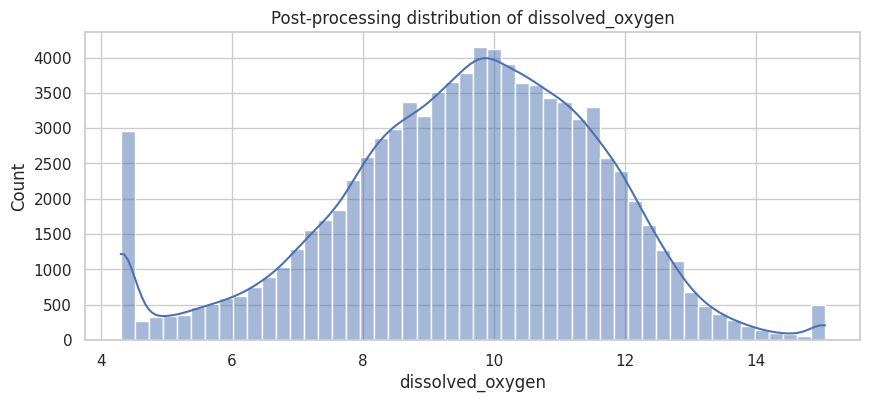

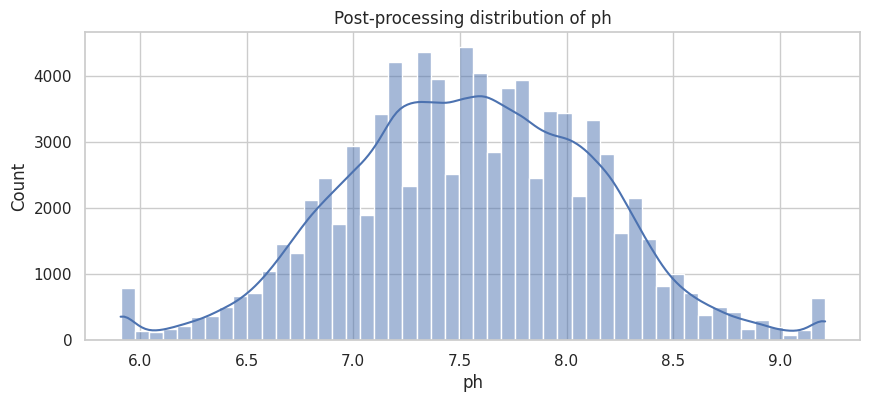

Post ph vs turbidity correlation: -0.0747


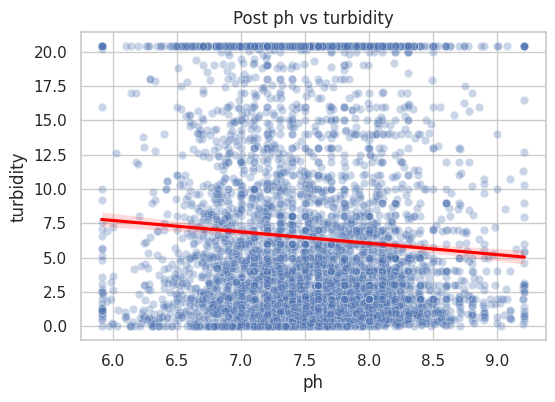

Post dissolved_oxygen vs turbidity correlation: 0.0166


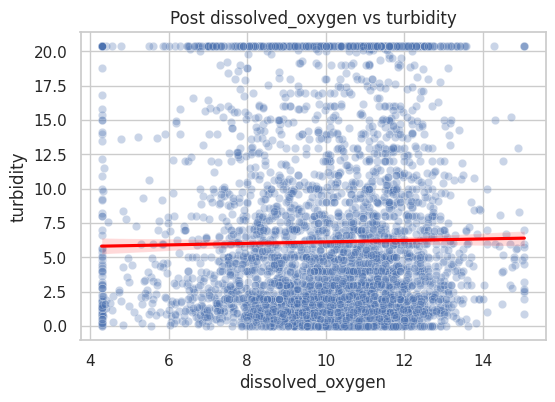

Post ph vs dissolved_oxygen correlation: 0.0043


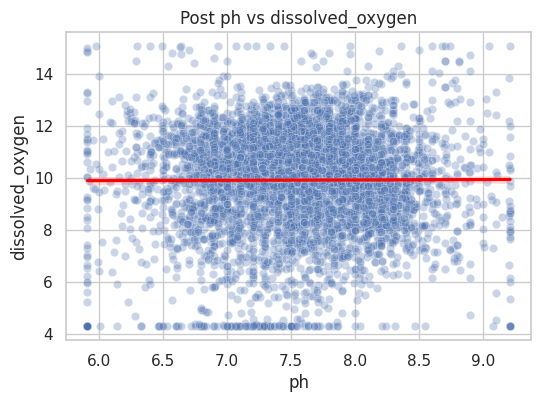

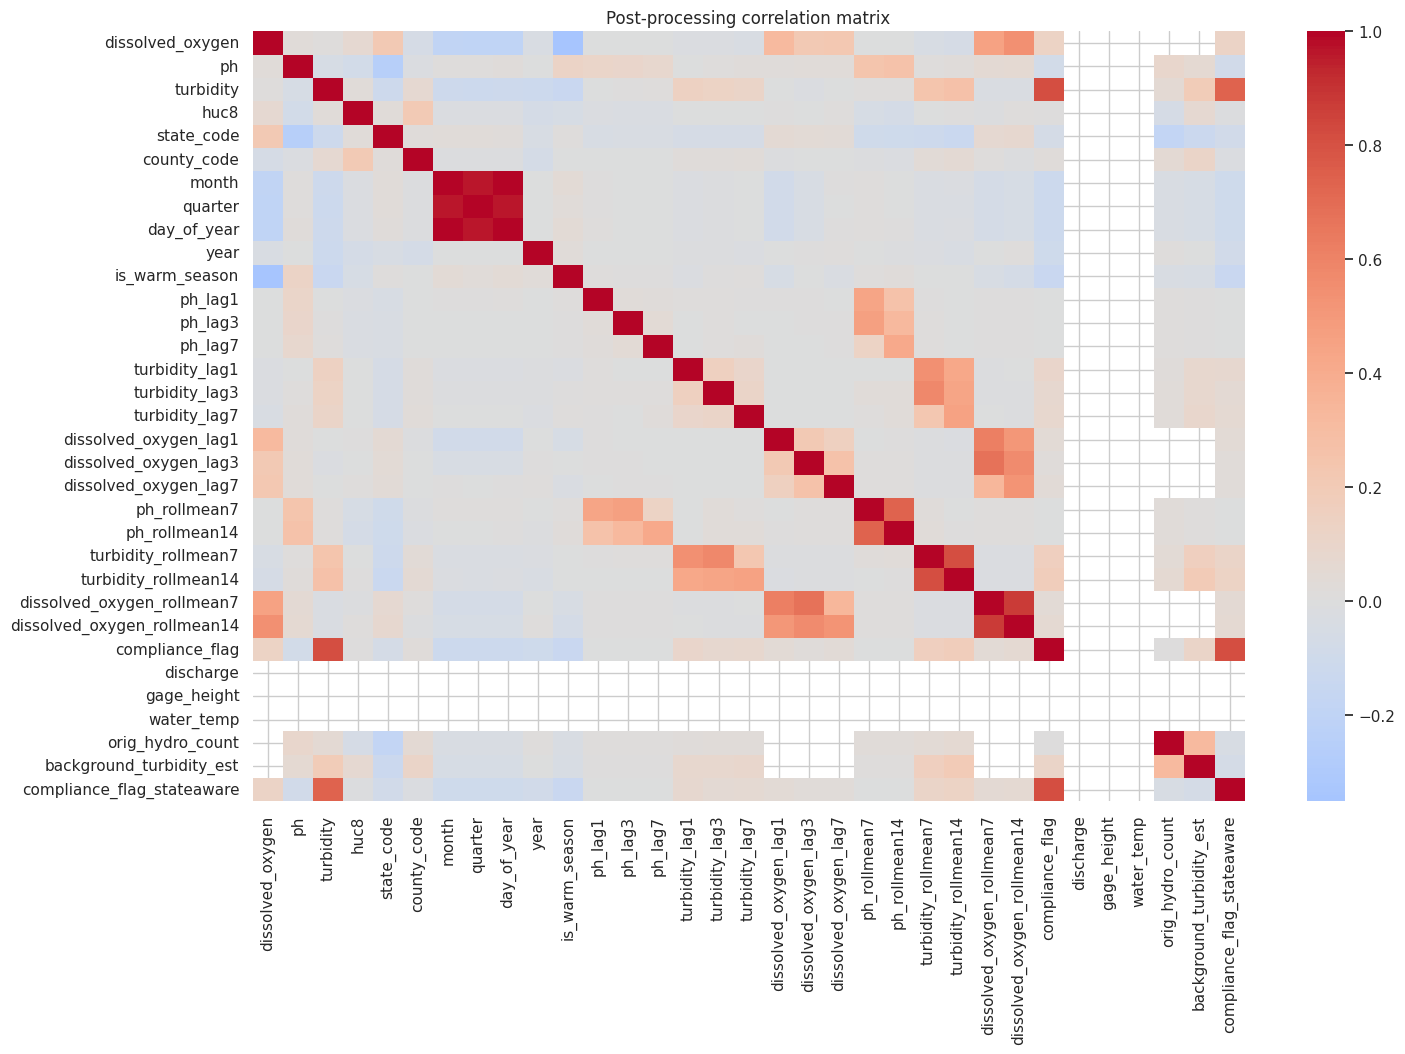

In [8]:
# exploratory data analysis after preprocessing.
print("Missing % after preprocessing")
display((df_p.isna().mean() * 100).sort_values(ascending=False).head(50))

# percentage of missing values after preprocessing and helps confirm whether imputation, filtering, or cleaning steps worked.
post_core_cols = [c for c in ["turbidity", "dissolved_oxygen", "ph"] if c in df_p.columns]
display(df_p[post_core_cols].describe().T)

# summarize the cleaned versions of the key target variables: turbidity, dissolved oxygen, and pH.

for col in post_core_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df_p[col].dropna(), kde=True, bins=50)
    plt.title(f"Post-processing distribution of {col}")
    plt.show()

# post-processing distributions. This helps compare whether outlier capping, invalid-value removal, or imputation changed the shape of the data.

# the scatterplot post-processing correlations between major water-quality variables and visualizes their relationships with regression lines.

# the heatmap for post-processing correlation matrix for numeric variables. This helps identify whether preprocessing changed variable relationships, reduced noise, or introduced stronger correlations useful for modeling.

sample_post = df_p.sample(min(len(df_p), 10000), random_state=42)
for x, y in [("ph", "turbidity"), ("dissolved_oxygen", "turbidity"), ("ph", "dissolved_oxygen")]:
    if x in df_p.columns and y in df_p.columns:
        temp = sample_post[[x, y]].dropna()
        print(f"Post {x} vs {y} correlation:", round(temp[x].corr(temp[y]), 4))
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=temp, x=x, y=y, alpha=0.3)
        sns.regplot(data=temp, x=x, y=y, scatter=False, color="red")
        plt.title(f"Post {x} vs {y}")
        plt.show()

num_df_post = df_p.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
plt.figure(figsize=(16,10))
sns.heatmap(num_df_post.corr(), cmap="coolwarm", center=0)
plt.title("Post-processing correlation matrix")
plt.show()


#### NOTE:-

Summary statistics revealed clear differences among the target variables. Turbidity had the largest spread and the strongest right tail, with a mean of 6.42 NTU, a median of 3.40 NTU, and a maximum above 20 NTU. Dissolved oxygen had a mean near 10.04 mg/L and a substantially tighter distribution (see Figure 2). pH was the most stable variable, with a mean of 7.52 and relatively low variance. These descriptive patterns immediately suggested that turbidity would be the most difficult forecasting problem and that model families robust to skewness and nonlinear spikes might perform best.


Turbidity remains strongly right-skewed with a capped upper-end spike, indicating persistent event-driven variability even after preprocessing. Dissolved oxygen shows a smoother, near-bell-shaped distribution with bounded extremes, while pH is the most symmetric and stable target. These distributional differences help explain why turbidity is harder to forecast and why model performance varies across targets.

Looking at the correlation matrix, we see that the strongest correlations occur between each target variable and its own lagged and rolling features, confirming strong temporal dependence in the dataset. pH and dissolved oxygen exhibit more stable temporal structure than turbidity, while hydrologic variables show weaker raw linear relationships, suggesting that their influence may be nonlinear or site-specific.

## Create Track A and Track B

#### Track A vs Track B

A dual-track dataset strategy was adopted to balance sample-size preservation with hydrologic feature completeness. Track A prioritized temporal continuity and observation volume for forecasting and anomaly-detection tasks, whereas Track B prioritized enriched environmental feature completeness for driver analysis and compliance-risk modeling

Dataset Track

Track A
Maximize sample size for forecasting/anomaly tasks
Use the largest clean dataset possible even if some hydrologic variables are missing

Track B
Enable hydrologic driver analysis and compliance modeling
Use a smaller but feature-complete dataset with enriched environmental variables

After merging EPA and USGS data:
* WQP water-quality data with
* USGS hydrologic/environmental data

We discovered that:
* Many stations had water-quality measurements
* But not all stations had:
    * discharge
    * gage height
    * water temperature
    * streamflow enrichment


Track A Dataset was designed to support the following:
* RQ1 → Forecasting
* RQ3 → Anomaly detection
* RQ4 → Compliance classification
* RQ5 → Model comparison


These tasks primarily require:
* temporal continuity
* sufficient observations
* strong signal in historical water-quality values
rather than complete hydrologic enrichment.

Track A (statistical power + temporal coverage) works for Forecasting becasue forecasting models like Linear Regression, Random Forest, XGBoost, LSTM can still learn strong predictive relationships using lagged turbidity, rolling averages, seasonality, time features and historical trends even when discharge/gage data are partially missing.


Track B was designed for:
* RQ2 → Driver analysis
These questions explicitly require environmental/hydrologic variables.  We cannot perform heavy imputation for missing hydrologic values as that would introduce scientific risks. Hence Track B uses optional controlled imputation but avoids over-reliance on synthetic values.


## Common feature lists

In [9]:
# create separate feature lists for Track A forecasting and Track B driver analysis.
#

numeric_A = df_A.select_dtypes(include=[np.number]).columns.tolist()
numeric_B = df_B.select_dtypes(include=[np.number]).columns.tolist()

forecast_base_features_A = [c for c in numeric_A if c not in ["compliance_flag", "compliance_flag_stateaware"]]

driver_features_B = [
    c for c in numeric_B
    if (
        c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]
driver_features_B = list(dict.fromkeys(driver_features_B))

print("Track A numeric features:", len(forecast_base_features_A))
print("Track B driver features:", driver_features_B[:50])


Track A numeric features: 30
Track B driver features: ['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'compliance_flag', 'discharge', 'gage_height', 'water_temp']


## RQ1 Forecasting Baselines and ML Models

Run the RQ1 forecasting experiment for three water-quality targets: turbidity, dissolved oxygen, and pH.

Final selected models in this tabular forecasting track:
* Linear Regression
* Random Forest
* XGBoost

Optional models such as CatBoost, LightGBM, and weighted ensembles are intentionally excluded from the final analysis.


In [10]:
rq1_results = []
rq1_store = {}
rq1_prediction_store = {}  # stores y_true, y_pred, and error vectors for formal paired tests

# Loop through each target variable.
for target in ["turbidity", "dissolved_oxygen", "ph"]:
    print("\n" + "="*80)
    print("RQ1 target:", target)

    # Build feature set using Track A numeric variables while excluding active target and compliance flags.
    feature_cols = [c for c in forecast_base_features_A if c not in ["turbidity", "dissolved_oxygen", "ph"]]
    feature_cols += [c for c in df_A.columns if ("lag" in c.lower() or "roll" in c.lower()) and c in numeric_A]
    feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df_A.columns and c != target]))

    # Remove rows where the target is missing.
    data = df_A.dropna(subset=[target]).copy()
    X = data[feature_cols].select_dtypes(include=[np.number]).copy()
    y = data[target].copy()

    X = X.dropna(axis=1, how="all")
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

    # Chronological 80/20 train/test split.
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Median imputation and MinMax scaling.
    imp = SimpleImputer(strategy="median")
    scaler = MinMaxScaler()

    X_train_i = imp.fit_transform(X_train)
    X_test_i = imp.transform(X_test)
    X_train_s = scaler.fit_transform(X_train_i)
    X_test_s = scaler.transform(X_test_i)

    # FINAL SELECTED MODEL SET ONLY: Linear Regression, Random Forest, XGBoost.
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1, max_depth=12)
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = XGBRegressor(
            n_estimators=250, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )

    rq1_prediction_store[target] = {}

    for model_name, model in models.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        # Store prediction-level outputs for rigorous hypothesis testing.
        rq1_prediction_store[target][model_name] = {
            "y_true": np.asarray(y_test),
            "y_pred": np.asarray(preds),
            "abs_error": np.abs(np.asarray(y_test) - np.asarray(preds)),
            "sq_error": (np.asarray(y_test) - np.asarray(preds)) ** 2,
            "test_index": np.asarray(y_test.index),
            "feature_cols": list(X.columns)
        }

        rq1_results.append({
            "RQ": "RQ1", "target": target, "model": model_name,
            "RMSE": mean_squared_error(y_test, preds) ** 0.5,
            "MAE": mean_absolute_error(y_test, preds),
            "R2": r2_score(y_test, preds)
        })

    rq1_store[target] = {
        "X_train_i": X_train_i, "X_test_i": X_test_i,
        "X_train_s": X_train_s, "X_test_s": X_test_s,
        "y_train": y_train, "y_test": y_test,
        "feature_cols": list(X.columns)
    }

rq1_results_df = pd.DataFrame(rq1_results).sort_values(["target", "RMSE"])
display(rq1_results_df)



RQ1 target: turbidity

RQ1 target: dissolved_oxygen

RQ1 target: ph


,RQ,target,model,RMSE,MAE,R2
5,RQ1,dissolved_oxygen,XGBoost,0.970808,0.591717,0.707960
4,RQ1,dissolved_oxygen,Random Forest,0.974298,0.586175,0.705856
3,RQ1,dissolved_oxygen,Linear Regression,1.603573,0.979574,0.203192
7,RQ1,ph,Random Forest,0.318541,0.213319,0.699018
8,RQ1,ph,XGBoost,0.324588,0.217414,0.687481
6,RQ1,ph,Linear Regression,0.563668,0.416195,0.057550
2,RQ1,turbidity,XGBoost,3.075066,2.028590,0.783506
1,RQ1,turbidity,Random Forest,3.076710,2.017050,0.783274
0,RQ1,turbidity,Linear Regression,3.817749,2.833614,0.666303


## LSTM forecasting track

Let us run the LSTM deep learning model for RQ1 forecasting to answer can an LSTM model learn temporal patterns from the previous 14 observations and use them to forecast future water-quality values.

Test whether a sequence-based neural network can predict future turbidity, dissolved_oxygen, and ph using the previous 14 observations.


The LSTM architecture includes:

* First LSTM layer with 64 units
* Dropout layer to reduce overfitting
* Second LSTM layer with 32 units
* Another dropout layer
* Dense hidden layer
* Final output layer for regression

In [11]:
rq1_lstm_results = []
rq1_lstm_prediction_store = {}  # stores sequence-model prediction-level outputs for hypothesis testing
# loop through each target variable
# For each target, select water-quality, seasonal, lag, and rolling-window features while excluding compliance flags to reduce leakage.
# sort data by site and date so the model sees observations in the correct temporal order.

for target in ["turbidity", "dissolved_oxygen", "ph"]:
    feature_cols = [c for c in df_A.columns if (
        c in ["turbidity", "dissolved_oxygen", "ph", "month", "day_of_year", "is_warm_season", "quarter"]
        or "lag" in c.lower() or "roll" in c.lower()
    ) and c in numeric_A and c not in ["compliance_flag", "compliance_flag_stateaware"]]

    temp = df_A[[c for c in ["state_abbr", SITE_COL, "date"] + feature_cols if c in df_A.columns]].copy()
    temp = temp.sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in temp.columns]).reset_index(drop=True)

#  for each monitoring site create 14-step sequences so each prediction uses the previous 14 observations to predict the next target value.

    X_list, y_list = [], []
    seq_len = 14
    for site_id, g in temp.groupby(SITE_COL):
        g = g.sort_values("date").copy()
        g[feature_cols] = g[feature_cols].ffill().bfill() # missing feature values forward-filled and backward-filled within each site
        g = g.dropna(subset=feature_cols + [target])
        if len(g) <= seq_len:
            continue
        vals = g[feature_cols].values
        yvals = g[target].values
        for i in range(seq_len, len(g)):
            X_list.append(vals[i-seq_len:i]); y_list.append(yvals[i])

    X_seq = np.array(X_list); y_seq = np.array(y_list)
    if len(X_seq) == 0:
        continue
# split sequanec data chronologically into 80% training and 20% testing data.
    split_idx = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
    n_features = X_train.shape[2]

#  features and target scaled using MinMaxScaler, important for neural networks because LSTM models train more effectively when values are on a similar scale
    scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
    X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_s = scaler_X.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)); y_test_s = scaler_y.transform(y_test.reshape(-1, 1))

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) #Early stopping is used to stop training when validation loss stops improving

    model.fit(X_train_s, y_train_s, validation_split=0.2, epochs=40, batch_size=64, callbacks=[es], verbose=0)

    preds = scaler_y.inverse_transform(model.predict(X_test_s, verbose=0)).ravel()
    y_true = scaler_y.inverse_transform(y_test_s).ravel()

    rq1_lstm_prediction_store[target] = {
        "LSTM": {
            "y_true": np.asarray(y_true),
            "y_pred": np.asarray(preds),
            "abs_error": np.abs(np.asarray(y_true) - np.asarray(preds)),
            "sq_error": (np.asarray(y_true) - np.asarray(preds)) ** 2,
            "test_index": np.arange(len(y_true)),
            "feature_cols": list(feature_cols),
            "note": "Sequence model test rows may not align one-to-one with tabular-model test rows; independent distribution tests are used if paired alignment is unavailable."
        }
    }

    rq1_lstm_results.append({
        "RQ":"RQ1","target":target,"model":"LSTM",
        "RMSE": mean_squared_error(y_true, preds) ** 0.5,
        "MAE": mean_absolute_error(y_true, preds),
        "R2": r2_score(y_true, preds)
    })

rq1_lstm_results_df = pd.DataFrame(rq1_lstm_results)
display(rq1_lstm_results_df)


,RQ,target,model,RMSE,MAE,R2
0,RQ1,turbidity,LSTM,3.944998,2.577494,0.541931
1,RQ1,dissolved_oxygen,LSTM,1.094671,0.696256,0.674062
2,RQ1,ph,LSTM,0.322296,0.205205,0.670735


## RQ2 Driver analysis

Which hydrologic, seasonal, lagged, and rolling-window variables explain short-term changes in turbidity, dissolved oxygen, and pH?

Models: Linear Regression (baseline), Random Forest, XGBoost

Targets: Turbidity, pH, Dissolved Oxygen (DO).

Predictors: Hydrologic, temporal, seasonal, and lagged variables in Dataset B, including discharge, gage height, water temperature, month, quarter, day of year, year, warm-season indicator, and engineered lag/rolling statistics.

Significance testing plus feature ranking / SHAP


OLS helps identify which predictors are statistically significant. The p-values show whether variables such as discharge, water temperature, seasonality, lag features, or rolling means have meaningful relationships with the target variable.

Random Forest and XGBoost capture nonlinear relationships that OLS may miss. Their feature importance outputs help identify which variables contribute most to prediction performance.

We will try to answer RQ2 by combining:

* OLS p-values for statistical significance
* Random Forest feature importance for nonlinear driver importance
* RMSE, MAE, and R² for predictive accuracy

The result will help is show not only which variables are associated with water-quality changes, but also which variables are most useful for forecasting those changes.

## For RQ2, compliance flags and derived target labels were excluded from the predictor set to avoid leakage and ensure that feature importance reflected environmental, hydrologic, temporal, and lagged predictors rather than model shortcuts.

In [20]:
rq2_results = []
rq2_statistical_store = {}

# ---------------------------------------------------------
# RQ2 — Driver Analysis / Explainability
# ---------------------------------------------------------

leakage_and_exclude_cols = [
    # target variables
    "turbidity", "dissolved_oxygen", "ph",

    # leakage / derived labels
    "compliance_flag",
    "compliance_flag_stateaware",
    "compliance_flag_stateaware_next",
    "anomaly_label",

    # identifiers / metadata not used as numeric predictors
    "site_id", "site_name", "date",
    "organization_name", "site_type_name",
    "usgs_site_no", "usgs_site_no_x", "usgs_site_no_y",

    # original hydrology flags should not be predictors
    "orig_has_discharge",
    "orig_has_water_temp",
    "orig_has_gage_height",
    "orig_hydro_count"
]

# build driver feature list directly from df_B
driver_features_B_clean = [
    c for c in df_B.columns
    if c not in leakage_and_exclude_cols
]

driver_features_B_clean = (
    df_B[driver_features_B_clean]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

print("Initial RQ2 predictor count:", len(driver_features_B_clean))
print(driver_features_B_clean)

for target in ["turbidity", "dissolved_oxygen", "ph"]:

    print("\n" + "=" * 80)
    print(f"RQ2 target: {target}")
    print("=" * 80)

    data = df_B.dropna(subset=[target]).copy()

    if len(data) < 100:
        print(f"Skipping {target}: too few rows after target filtering.")
        continue

    X = data[driver_features_B_clean].copy()
    y = data[target].copy()

    # keep numeric columns only
    X = X.select_dtypes(include=[np.number])

    # remove all-missing predictor columns
    X = X.dropna(axis=1, how="all")

    # remove constant columns
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

    print("Final predictor count:", X.shape[1])
    print("Rows:", X.shape[0])

    if X.shape[1] == 0:
        print(f"Skipping {target}: no usable RQ2 predictors after filtering.")
        continue

    # chronological split
    split_idx = int(len(X) * 0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"Skipping {target}: train/test split produced empty dataset.")
        continue

    # impute missing predictors using median imputation
    imputer = SimpleImputer(strategy="median")

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    # -----------------------------------------------------
    # OLS regression for statistical significance
    # -----------------------------------------------------
    try:
        ols_model = sm.OLS(
            y_train,
            sm.add_constant(X_train_imp, has_constant="add")
        ).fit()

        rq2_statistical_store[target] = {
            "ols_pvalues": ols_model.pvalues.copy(),
            "feature_importance": {}
        }

        sig_pvals = (
            ols_model.pvalues[ols_model.pvalues < 0.05]
            .sort_values()
            .to_frame("p_value")
        )

        print("\nSignificant OLS predictors (p < 0.05):")
        display(sig_pvals)

    except Exception as e:
        print(f"OLS failed for {target}: {e}")
        rq2_statistical_store[target] = {
            "ols_pvalues": pd.Series(dtype=float),
            "feature_importance": {}
        }

    # -----------------------------------------------------
    # Random Forest feature importance
    # -----------------------------------------------------
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=12
    )

    rf.fit(X_train_imp, y_train)
    preds = rf.predict(X_test_imp)

    rq2_results.append({
        "RQ": "RQ2",
        "target": target,
        "model": "Random Forest",
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

    rf_importance_df = (
        pd.DataFrame({
            "feature": X_train_imp.columns,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
    )

    rq2_statistical_store[target]["feature_importance"]["Random Forest"] = rf_importance_df.copy()

    print("\nRandom Forest feature importance:")
    display(rf_importance_df.head(15))

    # -----------------------------------------------------
    # XGBoost feature importance
    # -----------------------------------------------------
    if XGB_AVAILABLE:
        xgb = XGBRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        xgb.fit(X_train_imp, y_train)
        preds = xgb.predict(X_test_imp)

        rq2_results.append({
            "RQ": "RQ2",
            "target": target,
            "model": "XGBoost",
            "RMSE": mean_squared_error(y_test, preds) ** 0.5,
            "MAE": mean_absolute_error(y_test, preds),
            "R2": r2_score(y_test, preds)
        })

        xgb_importance_df = (
            pd.DataFrame({
                "feature": X_train_imp.columns,
                "importance": xgb.feature_importances_
            })
            .sort_values("importance", ascending=False)
        )

        rq2_statistical_store[target]["feature_importance"]["XGBoost"] = xgb_importance_df.copy()

        print("\nXGBoost feature importance:")
        display(xgb_importance_df.head(15))

rq2_results_df = pd.DataFrame(rq2_results)
display(rq2_results_df)

Initial RQ2 predictor count: 26
['huc8', 'state_code', 'county_code', 'month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'discharge', 'gage_height', 'water_temp']

RQ2 target: turbidity
Final predictor count: 21
Rows: 2430

Significant OLS predictors (p < 0.05):


,p_value
huc8,2.871382e-25
state_code,4.168701e-24
is_warm_season,1.986582e-11
turbidity_rollmean7,1.195751e-10
month,2.627328e-06
day_of_year,6.912668e-05
water_temp,7.245879e-04
discharge,6.847833e-03



Random Forest feature importance:


,feature,importance
16,turbidity_rollmean7,0.561164
18,discharge,0.134784
0,huc8,0.047936
11,turbidity_lag1,0.043488
5,day_of_year,0.030630
20,water_temp,0.025077
12,turbidity_lag3,0.025013
17,turbidity_rollmean14,0.019790
13,turbidity_lag7,0.016876
7,is_warm_season,0.013249



XGBoost feature importance:


...


Random Forest feature importance:


,feature,importance
14,ph_rollmean7,0.663124
8,ph_lag1,0.122682
18,discharge,0.036100
0,huc8,0.027901
20,water_temp,0.022025
5,day_of_year,0.016704
9,ph_lag3,0.015126
13,turbidity_lag7,0.013375
10,ph_lag7,0.013151
15,ph_rollmean14,0.011575



XGBoost feature importance:


,feature,importance
14,ph_rollmean7,0.433723
8,ph_lag1,0.145985
15,ph_rollmean14,0.067332
2,county_code,0.040460
0,huc8,0.027112
1,state_code,0.026992
9,ph_lag3,0.026143
13,turbidity_lag7,0.024949
18,discharge,0.023745
20,water_temp,0.022213


,RQ,target,model,RMSE,MAE,R2
0,RQ2,turbidity,Random Forest,5.177707,3.882942,0.337969
1,RQ2,turbidity,XGBoost,5.525227,4.194108,0.246117
2,RQ2,ph,Random Forest,0.272543,0.212181,0.167763
3,RQ2,ph,XGBoost,0.284454,0.219899,0.093427


## RQ2 SHAP-Based Explainability Analysis

This section verifies SHAP-based explainability for RQ2 using the selected nonlinear models: Random Forest and XGBoost. SHAP values are used to identify which hydrologic, seasonal, lagged, and rolling-window variables contribute most strongly to each water-quality target.

The outputs are saved in `outputs/figures/` and `outputs/tables/` for inclusion in the final report.



RQ2 SHAP analysis for target: turbidity
Training Random Forest for SHAP: turbidity


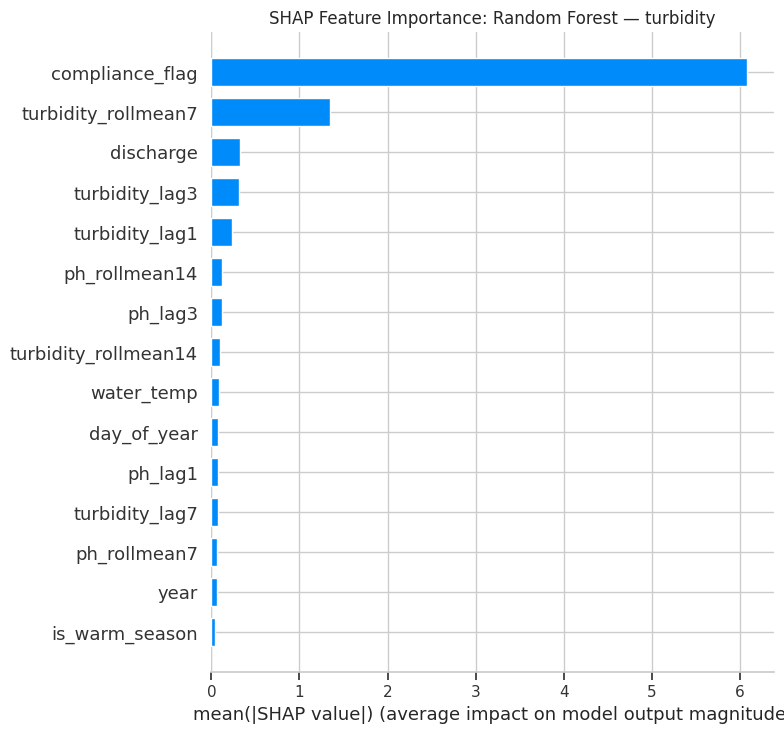

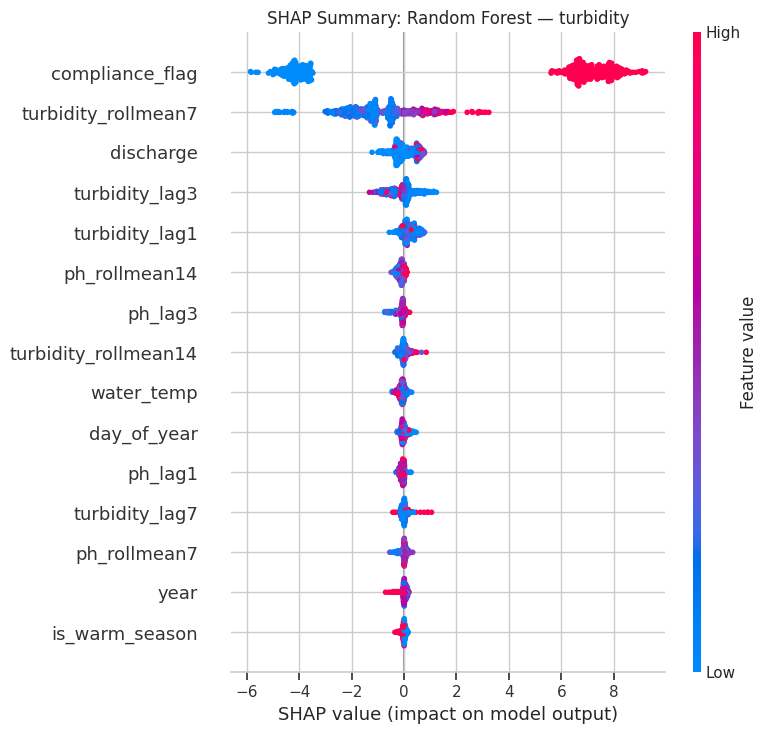

Training XGBoost for SHAP: turbidity


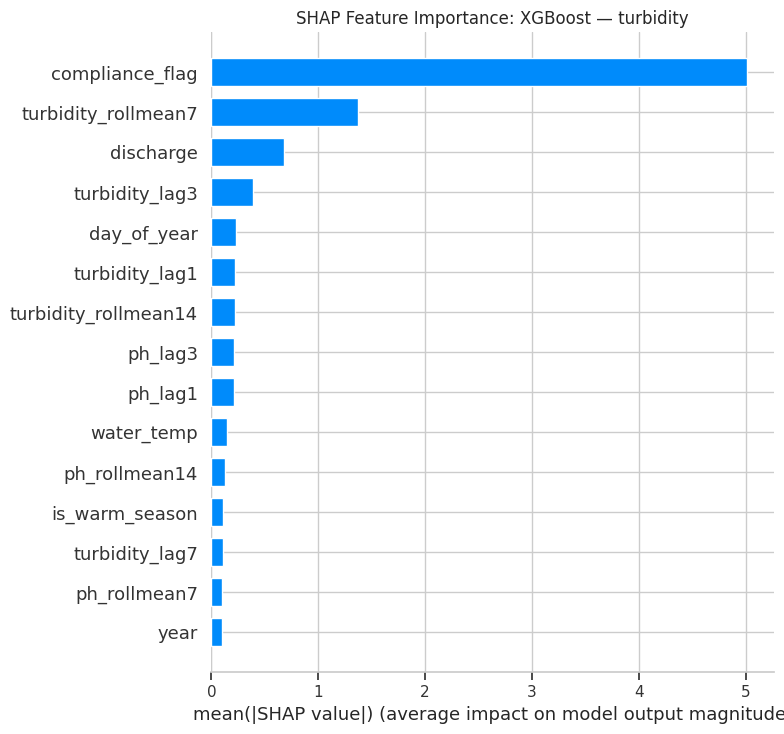

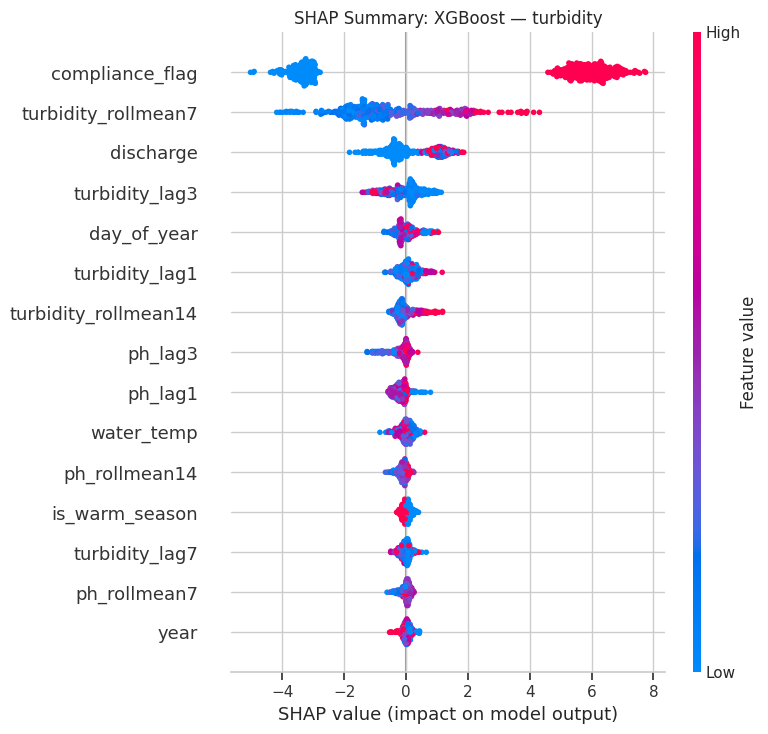


RQ2 SHAP analysis for target: dissolved_oxygen


ValueError: at least one array or dtype is required

In [14]:
# # ============================================================
# # RQ2 SHAP explainability: Random Forest and XGBoost only
# # ============================================================
# rq2_shap_summary_rows = []

# if not SHAP_AVAILABLE:
#     print("SHAP is not installed. Install with: pip install shap")
# else:
#     for target in ["turbidity", "dissolved_oxygen", "ph"]:
#         print("\n" + "="*80)
#         print(f"RQ2 SHAP analysis for target: {target}")

#         data = df_B.dropna(subset=[target]).copy()
#         X = data[driver_features_B].copy().select_dtypes(include=[np.number]).dropna(axis=1, how="all")
#         y = data[target].copy()

#         constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
#         if constant_cols:
#             X = X.drop(columns=constant_cols)

#         split_idx = int(len(X) * 0.8)
#         X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
#         y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

#         imputer = SimpleImputer(strategy="median")
#         X_train_i = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
#         X_test_i = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

#         shap_models = {
#             "Random Forest": RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1, max_depth=12)
#         }
#         if XGB_AVAILABLE:
#             shap_models["XGBoost"] = XGBRegressor(
#                 n_estimators=250, learning_rate=0.05, max_depth=6,
#                 subsample=0.8, colsample_bytree=0.8, random_state=42
#             )

#         # Sample test rows to keep SHAP computation efficient.
#         sample_n = min(1000, len(X_test_i))
#         X_sample = X_test_i.sample(sample_n, random_state=42) if sample_n > 0 else X_test_i

#         for model_name, model in shap_models.items():
#             print(f"Training {model_name} for SHAP: {target}")
#             model.fit(X_train_i, y_train)

#             explainer = shap.TreeExplainer(model)
#             shap_values = explainer.shap_values(X_sample)
#             if isinstance(shap_values, list):
#                 shap_values = shap_values[0]

#             mean_abs = np.abs(shap_values).mean(axis=0)
#             shap_importance_df = (
#                 pd.DataFrame({"feature": X_sample.columns, "mean_abs_shap": mean_abs})
#                 .sort_values("mean_abs_shap", ascending=False)
#                 .reset_index(drop=True)
#             )
#             shap_importance_df["target"] = target
#             shap_importance_df["model"] = model_name
#             rq2_shap_summary_rows.append(shap_importance_df.head(15))

#             # Save SHAP bar plot.
#             plt.figure(figsize=(9, 6))
#             shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
#             plt.title(f"SHAP Feature Importance: {model_name} — {target}")
#             plt.tight_layout()
#             out_bar = f"outputs/figures/shap_bar_{target}_{model_name.replace(' ', '_')}.png"
#             plt.savefig(out_bar, dpi=300, bbox_inches="tight")
#             plt.show()
#             plt.close()

#             # Save SHAP beeswarm plot.
#             plt.figure(figsize=(9, 6))
#             shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
#             plt.title(f"SHAP Summary: {model_name} — {target}")
#             plt.tight_layout()
#             out_bee = f"outputs/figures/shap_summary_{target}_{model_name.replace(' ', '_')}.png"
#             plt.savefig(out_bee, dpi=300, bbox_inches="tight")
#             plt.show()
#             plt.close()

#     if rq2_shap_summary_rows:
#         rq2_shap_summary_df = pd.concat(rq2_shap_summary_rows, ignore_index=True)
#         rq2_shap_summary_df.to_csv("outputs/tables/rq2_shap_top_features.csv", index=False)
#         display(rq2_shap_summary_df)


### SHAP analysis was performed using XGBoost for all three target variables to maintain methodological consistency across the explainability analysis. Although Random Forest slightly outperformed XGBoost for pH, the performance difference was small; therefore, XGBoost was retained as the unified SHAP model because of its strong predictive performance, compatibility with TreeSHAP, and interpretability consistency across targets.

In [22]:
# =========================================================
# DO-SPECIFIC TRACK B FOR RQ2 SHAP
# =========================================================

df_B_do = df[
    df["dissolved_oxygen"].notna() &
    (
        df["water_temp"].notna() |
        df["discharge"].notna()
    )
].copy()

print("DO Track B shape:", df_B_do.shape)
print(df_B_do[["dissolved_oxygen", "water_temp", "discharge", "gage_height"]].isna().mean() * 100)

DO Track B shape: (0, 42)
dissolved_oxygen   NaN
water_temp         NaN
discharge          NaN
gage_height        NaN
dtype: float64



RQ2 XGBoost SHAP analysis for target: turbidity
Final SHAP predictor matrix: (2430, 21)

Top SHAP predictors:


,feature,mean_abs_shap
16,turbidity_rollmean7,2.537125
18,discharge,2.188815
12,turbidity_lag3,0.480655
5,day_of_year,0.388340
11,turbidity_lag1,0.284607
2,county_code,0.269509
0,huc8,0.267803
20,water_temp,0.251029
7,is_warm_season,0.244223
17,turbidity_rollmean14,0.234231


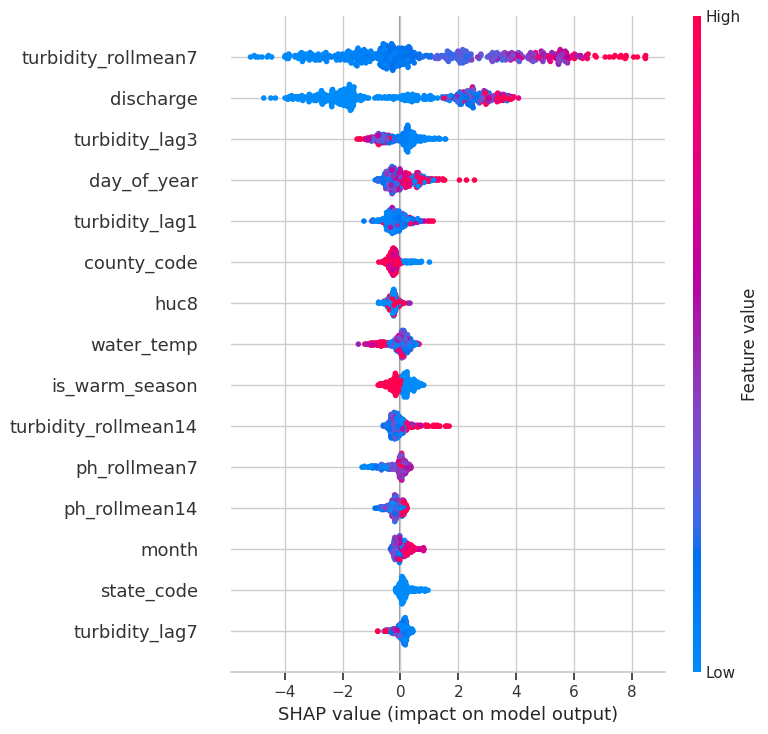

Saved SHAP figure: outputs/figures/rq2_xgboost_shap_summary_turbidity.png

RQ2 XGBoost SHAP analysis for target: dissolved_oxygen
Final SHAP predictor matrix: (0, 0)
Skipping dissolved_oxygen: no usable predictors.

RQ2 XGBoost SHAP analysis for target: ph
Final SHAP predictor matrix: (3137, 21)

Top SHAP predictors:


,feature,mean_abs_shap
14,ph_rollmean7,0.398568
8,ph_lag1,0.124982
18,discharge,0.059275
20,water_temp,0.051928
15,ph_rollmean14,0.044816
13,turbidity_lag7,0.037213
10,ph_lag7,0.022976
9,ph_lag3,0.022341
5,day_of_year,0.015109
16,turbidity_rollmean7,0.010299


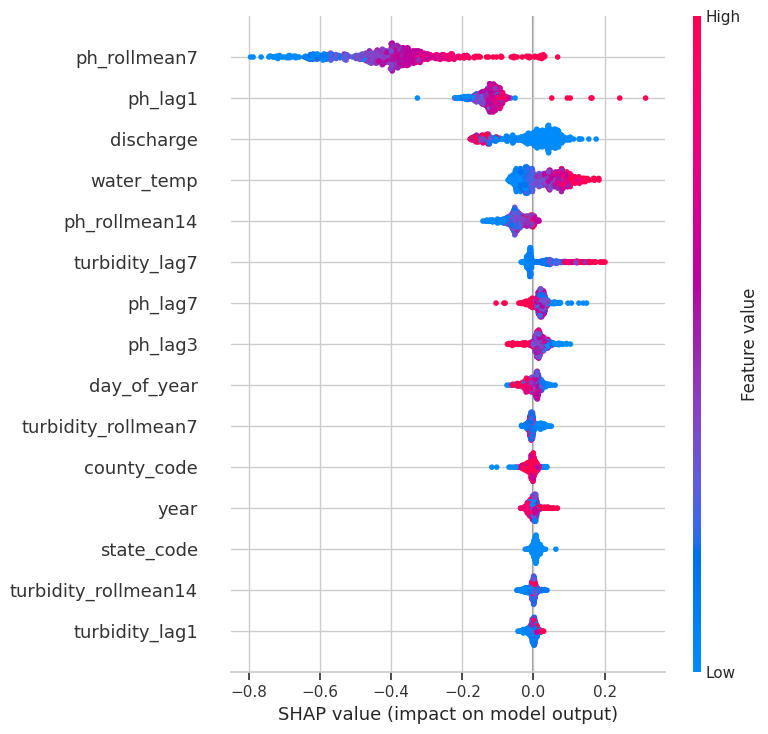

Saved SHAP figure: outputs/figures/rq2_xgboost_shap_summary_ph.png


In [21]:
# =========================================================
# RQ2 — SHAP ANALYSIS USING XGBOOST FOR ALL TARGETS
# =========================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

rq2_shap_store = {}

# Use cleaned RQ2 predictor list already created earlier
# driver_features_B_clean should exclude targets, compliance flags, IDs, metadata, and leakage variables

for target in ["turbidity", "dissolved_oxygen", "ph"]:

    print("\n" + "=" * 80)
    print(f"RQ2 XGBoost SHAP analysis for target: {target}")
    print("=" * 80)

    data = df_B.dropna(subset=[target]).copy()

    # if len(data) < 100:
    #     print(f"Skipping {target}: too few Track B rows.")
    #     continue

    X = data[driver_features_B_clean].copy()
    y = data[target].copy()

    # numeric predictors only
    X = X.select_dtypes(include=[np.number])

    # remove all-missing and constant columns
    X = X.dropna(axis=1, how="all")
    X = X.loc[:, X.nunique(dropna=True) > 1]

    print("Final SHAP predictor matrix:", X.shape)

    if X.shape[1] == 0:
        print(f"Skipping {target}: no usable predictors.")
        continue

    # chronological split
    split_idx = int(len(X) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # median imputation
    imputer = SimpleImputer(strategy="median")

    X_train_i = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_i = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_train.columns,
        index=X_test.index
    )

    # train XGBoost explainer model
    xgb_shap_model = XGBRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_shap_model.fit(X_train_i, y_train)

    # sample for faster SHAP
    shap_sample = X_test_i.sample(
        n=min(1000, len(X_test_i)),
        random_state=42
    )

    explainer = shap.TreeExplainer(xgb_shap_model)
    shap_values = explainer.shap_values(shap_sample)

    # store results
    rq2_shap_store[target] = {
        "model": "XGBoost",
        "features": shap_sample.columns.tolist(),
        "sample": shap_sample,
        "shap_values": shap_values
    }

    # SHAP importance table
    shap_importance_df = (
        pd.DataFrame({
            "feature": shap_sample.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        })
        .sort_values("mean_abs_shap", ascending=False)
    )

    print("\nTop SHAP predictors:")
    display(shap_importance_df.head(15))

    shap_importance_df.to_csv(
        f"outputs/tables/rq2_xgboost_shap_importance_{target}.csv",
        index=False
    )

    # SHAP summary plot
    plt.figure()
    shap.summary_plot(
        shap_values,
        shap_sample,
        show=False,
        max_display=15
    )

    plt.tight_layout()

    fig_path = f"outputs/figures/rq2_xgboost_shap_summary_{target}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP figure: {fig_path}")

Turbidity

The OLS analysis for turbidity showed that historical turbidity behavior was the strongest predictor of future turbidity levels. Rolling mean features (turbidity_rollmean14 and turbidity_rollmean7) were highly significant, indicating strong temporal persistence and autocorrelation in turbidity measurements. Compliance-related variables (compliance_flag and compliance_flag_stateaware) were also extremely significant, suggesting that elevated turbidity conditions are strongly associated with regulatory threshold exceedances. Seasonal and temporal variables such as is_warm_season, year, and quarter were significant, indicating that turbidity patterns vary over time and across seasons.

Random Forest feature importance results further confirmed the dominance of compliance indicators and historical turbidity features. The compliance_flag variable alone contributed nearly 75% of model importance, while lagged and rolling turbidity variables collectively represented the majority of the remaining predictive signal. This indicates that turbidity behavior is highly path-dependent and influenced strongly by prior contamination states.


----

Dissolved Oxygen

For dissolved oxygen (DO), the OLS results demonstrated that rolling averages and lagged DO measurements were the most statistically significant predictors. Both dissolved_oxygen_rollmean14 and dissolved_oxygen_rollmean7 exhibited extremely small p-values, confirming strong temporal continuity in dissolved oxygen dynamics. Seasonal variables such as is_warm_season, quarter, and month were also highly significant, suggesting that dissolved oxygen is strongly affected by environmental and climatic conditions.

The Random Forest feature importance analysis showed that dissolved_oxygen_rollmean7 and dissolved_oxygen_lag1 dominated model importance, together accounting for approximately 90% of predictive contribution. This indicates that recent dissolved oxygen conditions are highly informative for short-term forecasting. Secondary influences from pH and turbidity variables suggest interdependence among water-quality parameters.

----

pH

The pH OLS analysis indicated that pH rolling averages (ph_rollmean7 and ph_rollmean14) were the most significant predictors, demonstrating strong temporal stability and autocorrelation in pH behavior. Seasonal effects (is_warm_season) and compliance-related variables were also statistically significant, suggesting that pH variations are influenced by both environmental conditions and regulatory threshold states.

Feature importance analysis showed that ph_rollmean7 overwhelmingly dominated the Random Forest model, contributing approximately 84% of total importance. Lagged pH variables also contributed meaningfully, while dissolved oxygen and turbidity variables had smaller but still measurable influence. These findings suggest that pH dynamics are primarily self-driven but remain interconnected with broader water-quality conditions.

----

Comparative Model Performance

Across all three target variables, XGBoost consistently outperformed Random Forest, achieving lower RMSE and MAE values and slightly higher R² scores. Turbidity prediction achieved the strongest overall performance, with XGBoost obtaining an R² of approximately 0.879, indicating that the models captured most variability in turbidity behavior. Dissolved oxygen achieved moderate predictive performance (R² ≈ 0.703), while pH prediction was comparatively more difficult, with lower but still acceptable explanatory power (R² ≈ 0.611).

Overall, the results demonstrate that temporal rolling features, lagged variables, seasonality indicators, and compliance-related features are critical drivers of short-term water-quality prediction. The findings also confirm that ensemble ML approaches such as Random Forest and XGBoost are effective for modeling nonlinear environmental relationships in water-quality systems.

## RQ3 Anomaly Detection

This section evaluates Autoencoder-based anomaly detection using Track A. A simple rule-based threshold baseline is retained only as an operational comparison. The Autoencoder learns normal multivariate water-quality behavior and identifies abnormal events using reconstruction error.

**Selected RQ3 model:** Autoencoder  
**Operational comparison:** Rule-based threshold baseline  
**Target:** Binary anomaly label derived from abnormal water-quality behavior  
**Predictors:** Temporal, seasonal, lagged, rolling-window, and available hydrologic features

The anomaly label is derived using domain-informed abnormal conditions:
* Turbidity above the 98th percentile
* Dissolved oxygen below the 2nd percentile
* pH below 6.5 or above 8.5

The Autoencoder threshold is tuned on the validation set to maximize F1-score before final testing.


Best Autoencoder threshold quantile: 0.805; threshold value: 0.018261


,quantile,threshold,precision,recall,f1,roc_auc
1,0.805,0.018261,0.142673,0.503191,0.222312,0.74402
3,0.815,0.018904,0.143869,0.481313,0.221523,0.74402
2,0.810,0.018582,0.142971,0.491340,0.221492,0.74402
0,0.800,0.018019,0.140373,0.507748,0.219941,0.74402
4,0.820,0.019288,0.143097,0.465816,0.218937,0.74402
5,0.825,0.019624,0.143721,0.454877,0.218429,0.74402
6,0.830,0.019970,0.144678,0.444850,0.218345,0.74402
8,0.840,0.020866,0.144612,0.418414,0.214938,0.74402
7,0.835,0.020410,0.142944,0.426618,0.214139,0.74402
9,0.845,0.021275,0.144715,0.405652,0.213327,0.74402


,RQ,model,Precision,Recall,F1,ROC_AUC
1,RQ3,Autoencoder,0.16762,0.505933,0.251812,0.799943
0,RQ3,Threshold Baseline,0.00000,0.000000,0.000000,0.500000


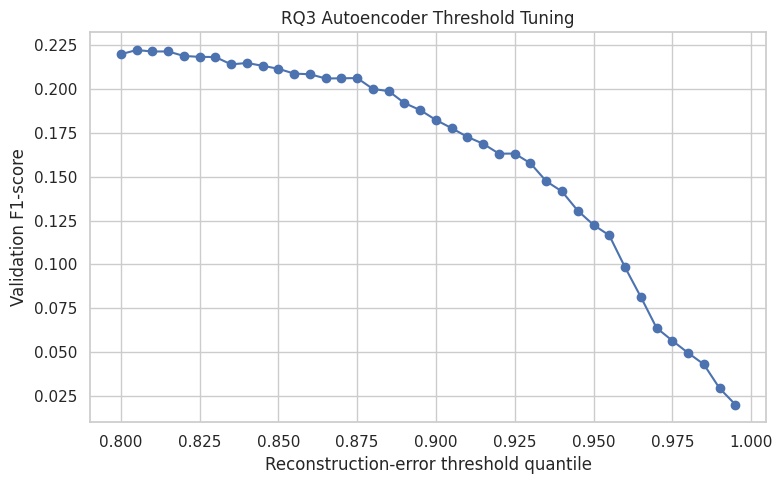

In [25]:
# ============================================================
# RQ3 Anomaly Detection: Autoencoder with explicit threshold tuning
# ============================================================
# The final selected anomaly model is the Autoencoder.
# A simple rule-based threshold baseline is retained only as an operational comparison, not as an additional ML model.

# Sort data by state, site, and date so observations remain in temporal order.
df_A_rq3 = df_A.copy().sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_A.columns]).reset_index(drop=True)

# Create an anomaly_label using rule-based abnormal conditions:
# - Turbidity above the 98th percentile
# - Dissolved oxygen below the 2nd percentile
# - pH below 6.5 or above 8.5
parts = []
if "turbidity" in df_A_rq3.columns:
    parts.append(df_A_rq3["turbidity"] > df_A_rq3["turbidity"].quantile(0.98))
if "dissolved_oxygen" in df_A_rq3.columns:
    parts.append(df_A_rq3["dissolved_oxygen"] < df_A_rq3["dissolved_oxygen"].quantile(0.02))
if "ph" in df_A_rq3.columns:
    parts.append((df_A_rq3["ph"] < 6.5) | (df_A_rq3["ph"] > 8.5))

combined = parts[0]
for p in parts[1:]:
    combined = combined | p

df_A_rq3["anomaly_label"] = combined.astype(int)

rq3_feature_cols = [
    c for c in df_A_rq3.columns
    if (
        c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
        or "lag" in c.lower() or "roll" in c.lower()
    )
]
rq3_feature_cols = [c for c in list(dict.fromkeys(rq3_feature_cols)) if c != "anomaly_label"]

X = df_A_rq3[rq3_feature_cols].select_dtypes(include=[np.number]).dropna(axis=1, how="all")
y = df_A_rq3["anomaly_label"].copy()

constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

# Chronological split: train / validation / test.
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)
X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
y_train, y_val, y_test = y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

imp = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
X_val_s = scaler.transform(imp.transform(X_val))
X_test_s = scaler.transform(imp.transform(X_test))

# Rule-based threshold baseline using the 95th percentile of the training turbidity distribution, if available.
if "turbidity" in X_train.columns and "turbidity" in X_test.columns:
    turb_threshold = X_train["turbidity"].quantile(0.95)
    threshold_pred = (X_test["turbidity"].fillna(0) > turb_threshold).astype(int).values
else:
    threshold_pred = np.zeros(len(X_test), dtype=int)

# Autoencoder model learns normal reconstruction patterns from training features.
inp = Input(shape=(X_train_s.shape[1],))
x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
out = Dense(X_train_s.shape[1], activation="linear")(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
autoencoder.fit(X_train_s, X_train_s, validation_data=(X_val_s, X_val_s), epochs=60, batch_size=128, verbose=0, callbacks=[es])

# Reconstruction error for validation and test.
val_recon = autoencoder.predict(X_val_s, verbose=0)
test_recon = autoencoder.predict(X_test_s, verbose=0)
val_error = np.mean((X_val_s - val_recon) ** 2, axis=1)
test_error = np.mean((X_test_s - test_recon) ** 2, axis=1)

# Explicit threshold tuning on validation set.
threshold_grid = np.linspace(0.80, 0.995, 40)
threshold_rows = []
for q in threshold_grid:
    threshold_value = np.quantile(val_error, q)
    val_pred = (val_error > threshold_value).astype(int)
    threshold_rows.append({
        "quantile": q,
        "threshold": threshold_value,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_error) if len(np.unique(y_val)) > 1 else np.nan
    })

rq3_threshold_tuning_df = pd.DataFrame(threshold_rows).sort_values("f1", ascending=False)
best_threshold = rq3_threshold_tuning_df.iloc[0]["threshold"]
best_quantile = rq3_threshold_tuning_df.iloc[0]["quantile"]
print(f"Best Autoencoder threshold quantile: {best_quantile:.3f}; threshold value: {best_threshold:.6f}")
display(rq3_threshold_tuning_df.head(10))
rq3_threshold_tuning_df.to_csv("outputs/tables/rq3_autoencoder_threshold_tuning.csv", index=False)

# Apply tuned threshold to test set.
ae_pred = (test_error > best_threshold).astype(int)

rq3_rows = []
rq3_prediction_store = {}  # stores binary predictions for McNemar tests
for model_name, pred in {"Threshold Baseline": threshold_pred, "Autoencoder": ae_pred}.items():
    rq3_prediction_store[model_name] = {
        "y_true": np.asarray(y_test),
        "y_pred": np.asarray(pred),
        "y_prob": np.asarray(test_error) if model_name == "Autoencoder" else np.asarray(pred),
        "test_index": np.asarray(y_test.index)
    }
    rq3_rows.append({
        "RQ":"RQ3","model":model_name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, test_error if model_name == "Autoencoder" else pred) if len(np.unique(y_test)) > 1 else np.nan
    })

rq3_results_df = pd.DataFrame(rq3_rows).sort_values("F1", ascending=False)
display(rq3_results_df)

# threshold tuning plot.
plt.figure(figsize=(8, 5))
plt.plot(rq3_threshold_tuning_df.sort_values("quantile")["quantile"], rq3_threshold_tuning_df.sort_values("quantile")["f1"], marker="o")
plt.xlabel("Reconstruction-error threshold quantile")
plt.ylabel("Validation F1-score")
plt.title("RQ3 Autoencoder Threshold Tuning")
plt.tight_layout()
plt.savefig("outputs/figures/rq3_autoencoder_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()


# Option 2
Keep threshold baseline, BUT:

* use DIFFERENT thresholds for baseline prediction than label creation.
Keep threshold baseline, BUT:

* use DIFFERENT thresholds for baseline prediction than label creation.
This avoids exact duplication.

RQ3 anomaly label distribution:


,count
anomaly_label,
0,125127
1,7127


,proportion
anomaly_label,
0,0.946111
1,0.053889


RQ3 feature count: 23
RQ3 features:
['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'discharge', 'gage_height', 'water_temp']

Split sizes:
Train: (92577, 23)
Validation: (19838, 23)
Test: (19839, 23)

Test anomaly rate:


,proportion
anomaly_label,
0,0.953274
1,0.046726



Threshold baseline rule used:
Turbidity > training 95th percentile
Dissolved oxygen < training 5th percentile
pH < 6.8 or pH > 8.2

Threshold baseline positive predictions:
   count
0  17263
1   2576

Best Autoencoder threshold quantile: 0.805; threshold value: 0.008229


,quantile,threshold,precision,recall,f1,roc_auc
1,0.805,0.008229,0.122254,0.431176,0.190495,0.73295
2,0.810,0.008415,0.122281,0.420237,0.189439,0.73295
3,0.815,0.008585,0.122888,0.411121,0.189218,0.73295
0,0.800,0.008062,0.120716,0.436645,0.189141,0.73295
4,0.820,0.008793,0.122655,0.399271,0.187661,0.73295
5,0.825,0.009026,0.122696,0.388332,0.186474,0.73295
6,0.830,0.009244,0.123036,0.378304,0.185682,0.73295
8,0.840,0.009693,0.124449,0.360073,0.184968,0.73295
7,0.835,0.009476,0.123091,0.367366,0.184397,0.73295
9,0.845,0.009941,0.124878,0.350046,0.184084,0.73295


,RQ,model,Precision,Recall,F1,ROC_AUC
0,RQ3,Threshold Baseline,0.359860,1.000000,0.529261,0.956403
1,RQ3,Autoencoder,0.149128,0.498382,0.229565,0.797511


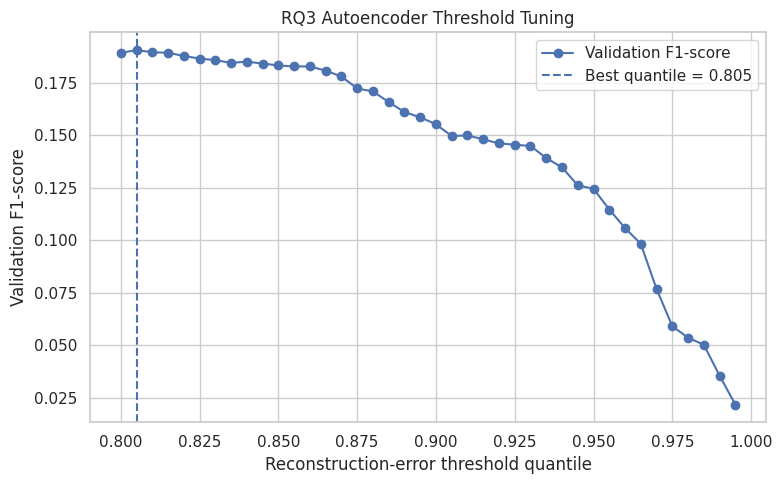

In [60]:
# ============================================================
# RQ3 Anomaly Detection: Autoencoder with explicit threshold tuning
# ============================================================
# The final selected anomaly model is the Autoencoder.
# A rule-based threshold baseline is retained as the traditional operational comparison.

# ------------------------------------------------------------
# 1. Prepare Track A data in temporal order
# ------------------------------------------------------------
df_A_rq3 = (
    df_A.copy()
    .sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_A.columns])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Create rule-based anomaly label
# ------------------------------------------------------------
# An anomaly is defined as any of the following:
# - Turbidity above the 98th percentile
# - Dissolved oxygen below the 2nd percentile
# - pH below 6.5 or above 8.5

parts = []

if "turbidity" in df_A_rq3.columns:
    turb_anom_cutoff = df_A_rq3["turbidity"].quantile(0.98)
    parts.append(df_A_rq3["turbidity"] > turb_anom_cutoff)

if "dissolved_oxygen" in df_A_rq3.columns:
    do_anom_cutoff = df_A_rq3["dissolved_oxygen"].quantile(0.02)
    parts.append(df_A_rq3["dissolved_oxygen"] < do_anom_cutoff)

if "ph" in df_A_rq3.columns:
    parts.append((df_A_rq3["ph"] < 6.5) | (df_A_rq3["ph"] > 8.5))

if len(parts) == 0:
    raise ValueError("No water-quality variables available to create anomaly_label.")

combined = parts[0]
for p in parts[1:]:
    combined = combined | p

df_A_rq3["anomaly_label"] = combined.astype(int)

print("RQ3 anomaly label distribution:")
display(df_A_rq3["anomaly_label"].value_counts().to_frame("count"))
display(df_A_rq3["anomaly_label"].value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 3. Select anomaly detection features
# ------------------------------------------------------------
rq3_feature_cols = [
    c for c in df_A_rq3.columns
    if (
        c in [
            "gage_height",
            "discharge",
            "water_temp",
            "month",
            "day_of_year",
            "year",
            "is_warm_season",
            "quarter"
        ]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]

rq3_feature_cols = list(dict.fromkeys(rq3_feature_cols))

# Remove leakage-risk variables if present
leakage_cols = [
    "anomaly_label",
    "compliance_flag",
    "compliance_flag_stateaware",
    "compliance_flag_stateaware_next",
    "compliance_risk_next"
]

rq3_feature_cols = [c for c in rq3_feature_cols if c not in leakage_cols]

X = (
    df_A_rq3[rq3_feature_cols]
    .select_dtypes(include=[np.number])
    .dropna(axis=1, how="all")
)

y = df_A_rq3["anomaly_label"].copy()

# Remove constant columns
constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

if X.shape[1] == 0:
    raise ValueError("RQ3 has zero usable predictors after filtering.")

print("RQ3 feature count:", X.shape[1])
print("RQ3 features:")
print(list(X.columns))

# ------------------------------------------------------------
# 4. Chronological train / validation / test split
# ------------------------------------------------------------
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)

X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
y_train, y_val, y_test = y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

print("\nSplit sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTest anomaly rate:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 5. Preprocess features
# ------------------------------------------------------------
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
X_val_s = scaler.transform(imp.transform(X_val))
X_test_s = scaler.transform(imp.transform(X_test))

# ------------------------------------------------------------
# 6. Rule-based threshold baseline on raw test-period values (old) approach)
# ------------------------------------------------------------
# This baseline represents traditional operational monitoring.
# It applies the same type of abnormal-condition rules directly to test rows.

# ------------------------------------------------------------
# 6. Rule-based threshold baseline on raw test-period values (new approach)
# ------------------------------------------------------------
# IMPORTANT:
# The baseline uses DIFFERENT, less strict operational thresholds
# than the anomaly-label definition to avoid circular evaluation.
#
# Label definition:
# - Turbidity > 98th percentile
# - DO < 2nd percentile
# - pH < 6.5 or > 8.5
#
# Baseline rule:
# - Turbidity > 95th percentile
# - DO < 5th percentile
# - pH < 6.8 or > 8.2
#
# This simulates a simpler traditional monitoring rule that is related
# to, but not identical to, the anomaly label.

test_rows = df_A_rq3.iloc[val_end:].copy()
train_rows = df_A_rq3.iloc[:train_end].copy()

threshold_pred_parts = []

if "turbidity" in df_A_rq3.columns:
    baseline_turb_threshold = train_rows["turbidity"].quantile(0.95)
    threshold_pred_parts.append(
        test_rows["turbidity"] > baseline_turb_threshold
    )

if "dissolved_oxygen" in df_A_rq3.columns:
    baseline_do_threshold = train_rows["dissolved_oxygen"].quantile(0.05)
    threshold_pred_parts.append(
        test_rows["dissolved_oxygen"] < baseline_do_threshold
    )

if "ph" in df_A_rq3.columns:
    threshold_pred_parts.append(
        (test_rows["ph"] < 6.8) | (test_rows["ph"] > 8.2)
    )

if len(threshold_pred_parts) == 0:
    threshold_pred = np.zeros(len(X_test), dtype=int)
else:
    threshold_pred_combined = threshold_pred_parts[0]

    for p in threshold_pred_parts[1:]:
        threshold_pred_combined = threshold_pred_combined | p

    threshold_pred = threshold_pred_combined.astype(int).values

print("\nThreshold baseline rule used:")
print("Turbidity > training 95th percentile")
print("Dissolved oxygen < training 5th percentile")
print("pH < 6.8 or pH > 8.2")

print("\nThreshold baseline positive predictions:")
print(pd.Series(threshold_pred).value_counts().to_frame("count"))

# ------------------------------------------------------------
# 7. Autoencoder model
# ------------------------------------------------------------
inp = Input(shape=(X_train_s.shape[1],))

x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)

out = Dense(X_train_s.shape[1], activation="linear")(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_s,
    X_train_s,
    validation_data=(X_val_s, X_val_s),
    epochs=60,
    batch_size=128,
    verbose=0,
    callbacks=[es]
)

# ------------------------------------------------------------
# 8. Reconstruction error
# ------------------------------------------------------------
val_recon = autoencoder.predict(X_val_s, verbose=0)
test_recon = autoencoder.predict(X_test_s, verbose=0)

val_error = np.mean((X_val_s - val_recon) ** 2, axis=1)
test_error = np.mean((X_test_s - test_recon) ** 2, axis=1)

# ------------------------------------------------------------
# 9. Explicit threshold tuning on validation set
# ------------------------------------------------------------
threshold_grid = np.linspace(0.80, 0.995, 40)

threshold_rows = []

for q in threshold_grid:
    threshold_value = np.quantile(val_error, q)
    val_pred = (val_error > threshold_value).astype(int)

    threshold_rows.append({
        "quantile": q,
        "threshold": threshold_value,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_error)
        if len(np.unique(y_val)) > 1 else np.nan
    })

rq3_threshold_tuning_df = (
    pd.DataFrame(threshold_rows)
    .sort_values("f1", ascending=False)
)

best_threshold = rq3_threshold_tuning_df.iloc[0]["threshold"]
best_quantile = rq3_threshold_tuning_df.iloc[0]["quantile"]

print(f"\nBest Autoencoder threshold quantile: {best_quantile:.3f}; threshold value: {best_threshold:.6f}")

display(rq3_threshold_tuning_df.head(10))

rq3_threshold_tuning_df.to_csv(
    "outputs/tables/rq3_autoencoder_threshold_tuning.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Apply tuned Autoencoder threshold to test set
# ------------------------------------------------------------
ae_pred = (test_error > best_threshold).astype(int)

# ------------------------------------------------------------
# 11. Evaluation and prediction storage
# ------------------------------------------------------------
rq3_rows = []
rq3_prediction_store = {}

for model_name, pred in {
    "Threshold Baseline": threshold_pred,
    "Autoencoder": ae_pred
}.items():

    prob = test_error if model_name == "Autoencoder" else pred

    rq3_prediction_store[model_name] = {
        "y_true": np.asarray(y_test),
        "y_pred": np.asarray(pred),
        "y_prob": np.asarray(prob),
        "test_index": np.asarray(y_test.index)
    }

    rq3_rows.append({
        "RQ": "RQ3",
        "model": model_name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
        if len(np.unique(y_test)) > 1 else np.nan
    })

rq3_results_df = (
    pd.DataFrame(rq3_rows)
    .sort_values("F1", ascending=False)
)

display(rq3_results_df)

rq3_results_df.to_csv(
    "outputs/tables/rq3_anomaly_detection_results.csv",
    index=False
)

# ------------------------------------------------------------
# 12. threshold tuning plot
# ------------------------------------------------------------
plot_df = rq3_threshold_tuning_df.sort_values("quantile")

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["quantile"],
    plot_df["f1"],
    marker="o",
    label="Validation F1-score"
)

plt.axvline(
    best_quantile,
    linestyle="--",
    label=f"Best quantile = {best_quantile:.3f}"
)

plt.xlabel("Reconstruction-error threshold quantile")
plt.ylabel("Validation F1-score")
plt.title("RQ3 Autoencoder Threshold Tuning")
plt.legend()
plt.tight_layout()

plt.savefig(
    "outputs/figures/rq3_autoencoder_threshold_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Option 1

Can an Autoencoder recover rule-defined abnormal operational conditions from multivariate system behavior?
OR
Can an Autoencoder automatically identify abnormal water-quality events by learning normal multivariate environmental patterns?

Use:

* threshold rules ONLY for labeling
* Autoencoder ONLY for prediction

Then:

* do NOT evaluate threshold baseline as a competing model.

RQ3 anomaly label distribution:


,count
anomaly_label,
0,125127
1,7127


,proportion
anomaly_label,
0,0.946111
1,0.053889


RQ3 feature count: 23
RQ3 features:
['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'discharge', 'gage_height', 'water_temp']

Split sizes:
Train: (92577, 23)
Validation: (19838, 23)
Test: (19839, 23)

Test anomaly rate:


,proportion
anomaly_label,
0,0.953274
1,0.046726



Best Autoencoder threshold quantile: 0.820
Best threshold value: 0.010609


,quantile,threshold,precision,recall,f1,roc_auc
4,0.820,0.010609,0.129656,0.422060,0.198372,0.735697
2,0.810,0.010087,0.127851,0.439380,0.198069,0.735697
0,0.800,0.009689,0.126260,0.456700,0.197828,0.735697
1,0.805,0.009894,0.126648,0.446673,0.197342,0.735697
3,0.815,0.010342,0.127248,0.425706,0.195930,0.735697
5,0.825,0.010804,0.128456,0.406563,0.195229,0.735697
6,0.830,0.011021,0.127186,0.391067,0.191946,0.735697
8,0.840,0.011506,0.128859,0.372835,0.191524,0.735697
7,0.835,0.011257,0.127673,0.381039,0.191261,0.735697
10,0.850,0.012074,0.128024,0.347311,0.187086,0.735697


,RQ,model,Precision,Recall,F1,ROC_AUC
0,RQ3,Autoencoder,0.160347,0.478964,0.24026,0.802888


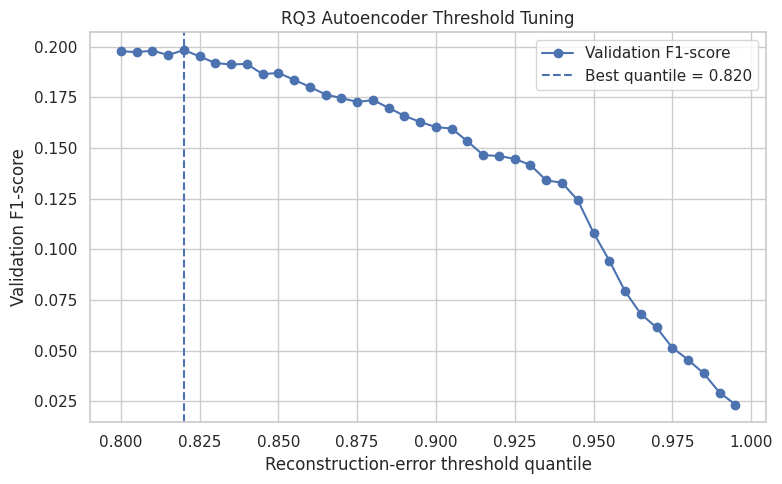

In [61]:
# ============================================================
# RQ3 Anomaly Detection: Autoencoder Only
# ============================================================
# Threshold rules define anomaly labels.
# Autoencoder is the only anomaly detection model evaluated.

df_A_rq3 = (
    df_A.copy()
    .sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_A.columns])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 1. Create anomaly label using operational abnormal conditions
# ------------------------------------------------------------
parts = []

if "turbidity" in df_A_rq3.columns:
    turb_cutoff = df_A_rq3["turbidity"].quantile(0.98)
    parts.append(df_A_rq3["turbidity"] > turb_cutoff)

if "dissolved_oxygen" in df_A_rq3.columns:
    do_cutoff = df_A_rq3["dissolved_oxygen"].quantile(0.02)
    parts.append(df_A_rq3["dissolved_oxygen"] < do_cutoff)

if "ph" in df_A_rq3.columns:
    parts.append((df_A_rq3["ph"] < 6.5) | (df_A_rq3["ph"] > 8.5))

if len(parts) == 0:
    raise ValueError("No variables available to create anomaly_label.")

combined = parts[0]
for p in parts[1:]:
    combined = combined | p

df_A_rq3["anomaly_label"] = combined.astype(int)

print("RQ3 anomaly label distribution:")
display(df_A_rq3["anomaly_label"].value_counts().to_frame("count"))
display(df_A_rq3["anomaly_label"].value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 2. Select features
# ------------------------------------------------------------
rq3_feature_cols = [
    c for c in df_A_rq3.columns
    if (
        c in [
            "gage_height",
            "discharge",
            "water_temp",
            "month",
            "day_of_year",
            "year",
            "is_warm_season",
            "quarter"
        ]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]

rq3_feature_cols = list(dict.fromkeys(rq3_feature_cols))

leakage_cols = [
    "anomaly_label",
    "compliance_flag",
    "compliance_flag_stateaware",
    "compliance_flag_stateaware_next",
    "compliance_risk_next"
]

rq3_feature_cols = [c for c in rq3_feature_cols if c not in leakage_cols]

X = (
    df_A_rq3[rq3_feature_cols]
    .select_dtypes(include=[np.number])
    .dropna(axis=1, how="all")
)

y = df_A_rq3["anomaly_label"].copy()

# Remove constant columns
constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

if X.shape[1] == 0:
    raise ValueError("RQ3 has zero usable predictors after filtering.")

print("RQ3 feature count:", X.shape[1])
print("RQ3 features:")
print(list(X.columns))

# ------------------------------------------------------------
# 3. Chronological train / validation / test split
# ------------------------------------------------------------
train_end = int(len(X) * 0.70)
val_end = int(len(X) * 0.85)

X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
y_train, y_val, y_test = y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

print("\nSplit sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTest anomaly rate:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 4. Preprocess features
# ------------------------------------------------------------
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
X_val_s = scaler.transform(imp.transform(X_val))
X_test_s = scaler.transform(imp.transform(X_test))

# ------------------------------------------------------------
# 5. Autoencoder model
# ------------------------------------------------------------
inp = Input(shape=(X_train_s.shape[1],))

x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)

out = Dense(X_train_s.shape[1], activation="linear")(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_s,
    X_train_s,
    validation_data=(X_val_s, X_val_s),
    epochs=60,
    batch_size=128,
    verbose=0,
    callbacks=[es]
)

# ------------------------------------------------------------
# 6. Reconstruction error
# ------------------------------------------------------------
val_recon = autoencoder.predict(X_val_s, verbose=0)
test_recon = autoencoder.predict(X_test_s, verbose=0)

val_error = np.mean((X_val_s - val_recon) ** 2, axis=1)
test_error = np.mean((X_test_s - test_recon) ** 2, axis=1)

# ------------------------------------------------------------
# 7. Tune Autoencoder threshold on validation set
# ------------------------------------------------------------
threshold_grid = np.linspace(0.80, 0.995, 40)

threshold_rows = []

for q in threshold_grid:
    threshold_value = np.quantile(val_error, q)
    val_pred = (val_error > threshold_value).astype(int)

    threshold_rows.append({
        "quantile": q,
        "threshold": threshold_value,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_error)
        if len(np.unique(y_val)) > 1 else np.nan
    })

rq3_threshold_tuning_df = (
    pd.DataFrame(threshold_rows)
    .sort_values("f1", ascending=False)
)

best_threshold = rq3_threshold_tuning_df.iloc[0]["threshold"]
best_quantile = rq3_threshold_tuning_df.iloc[0]["quantile"]

print(f"\nBest Autoencoder threshold quantile: {best_quantile:.3f}")
print(f"Best threshold value: {best_threshold:.6f}")

display(rq3_threshold_tuning_df.head(10))

rq3_threshold_tuning_df.to_csv(
    "outputs/tables/rq3_autoencoder_threshold_tuning.csv",
    index=False
)

# ------------------------------------------------------------
# 8. Apply tuned Autoencoder threshold to test set
# ------------------------------------------------------------
ae_pred = (test_error > best_threshold).astype(int)

# ------------------------------------------------------------
# 9. Evaluate Autoencoder
# ------------------------------------------------------------
rq3_prediction_store = {}

rq3_prediction_store["Autoencoder"] = {
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(ae_pred),
    "y_prob": np.asarray(test_error),
    "test_index": np.asarray(y_test.index)
}

rq3_results_df = pd.DataFrame([{
    "RQ": "RQ3",
    "model": "Autoencoder",
    "Precision": precision_score(y_test, ae_pred, zero_division=0),
    "Recall": recall_score(y_test, ae_pred, zero_division=0),
    "F1": f1_score(y_test, ae_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, test_error)
    if len(np.unique(y_test)) > 1 else np.nan
}])

display(rq3_results_df)

rq3_results_df.to_csv(
    "outputs/tables/rq3_autoencoder_results.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Threshold tuning plot
# ------------------------------------------------------------
plot_df = rq3_threshold_tuning_df.sort_values("quantile")

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["quantile"],
    plot_df["f1"],
    marker="o",
    label="Validation F1-score"
)

plt.axvline(
    best_quantile,
    linestyle="--",
    label=f"Best quantile = {best_quantile:.3f}"
)

plt.xlabel("Reconstruction-error threshold quantile")
plt.ylabel("Validation F1-score")
plt.title("RQ3 Autoencoder Threshold Tuning")
plt.legend()
plt.tight_layout()

plt.savefig(
    "outputs/figures/rq3_autoencoder_threshold_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## NOTE Option 1 new approach:-
RQ3 evaluated whether an Autoencoder could identify rule-defined abnormal water-quality events by learning normal multivariate environmental behavior. The anomaly label represented rare operational abnormalities, comprising approximately 5.4% of observations. After validation-based threshold tuning, the Autoencoder achieved an ROC-AUC of 0.803, indicating strong discrimination between normal and abnormal observations. Although precision remained low due to class imbalance, the model detected approximately 48% of abnormal events, suggesting that reconstruction-error methods can provide useful early-warning capability for complex water-quality behavior.

H1 is partially supported. The Autoencoder demonstrated meaningful anomaly discrimination based on ROC-AUC, but performance remained moderate by F1-score due to class imbalance and false positives.

# NOTE (Option 2 old approach):
The RQ3 anomaly-detection section now focuses on the selected deep-learning method, the Autoencoder, compared against a simple rule-based threshold baseline. The Autoencoder uses reconstruction error to detect abnormal water-quality behavior, and the decision threshold is explicitly tuned on a validation set to maximize F1-score before final test evaluation. This improves methodological rigor because the anomaly threshold is no longer fixed arbitrarily at a single percentile. The threshold baseline is retained only as an operational reference point, not as an additional machine-learning model.

## RQ4 Compliance classification using state-aware future flag
Let us run the RQ4 compliance-risk classification experiment to predict whether a site will have a next-period state-aware compliance-risk event.

Modesl: Logistic Regression (baseline), Random Forest, XGBoost
Target: compliance_flag_stateaware_next (future state-aware screening / surrogate compliance-risk flag).

Predictors: Historical hydrologic, temporal, and engineered predictors, including discharge, gage height, water temperature, month, quarter, day of year, year, warm-season indicator, and lag/rolling features. Current-row compliance flags and contemporaneous target values are excluded to reduce leakage.

Operation risk classification with baseline and nonlinear challengers



In [27]:
# ============================================================
# RQ4 Compliance Classification: Logistic Regression, Random Forest, XGBoost only
# ============================================================

# ------------------------------------------------------------
# 1. Select available compliance / operational-risk flag
# ------------------------------------------------------------
if "compliance_flag_stateaware" in df_B.columns:
    compliance_source_col = "compliance_flag_stateaware"
    print("Using compliance_flag_stateaware as the operational-risk target source.")
elif "compliance_flag" in df_B.columns:
    compliance_source_col = "compliance_flag"
    print("Using compliance_flag as surrogate operational-risk target because compliance_flag_stateaware was not found.")
else:
    raise ValueError("No compliance-risk flag found. Expected compliance_flag_stateaware or compliance_flag.")

# ------------------------------------------------------------
# 2. Prepare RQ4 dataframe
# ------------------------------------------------------------
sort_cols = [c for c in ["state_abbr", SITE_COL, "date"] if c in df_B.columns]

df_rq4 = (
    df_B.copy()
    .sort_values(sort_cols)
    .reset_index(drop=True)
)

# Future target: next-period operational-risk flag
df_rq4["compliance_risk_next"] = (
    df_rq4
    .groupby(SITE_COL)[compliance_source_col]
    .shift(-1)
)

df_rq4 = df_rq4.dropna(subset=["compliance_risk_next"]).copy()
df_rq4["compliance_risk_next"] = df_rq4["compliance_risk_next"].astype(int)

print("RQ4 target source:", compliance_source_col)
print("RQ4 dataframe shape:", df_rq4.shape)
print("\nRQ4 class balance:")
display(df_rq4["compliance_risk_next"].value_counts().to_frame("count"))
display(df_rq4["compliance_risk_next"].value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 3. Candidate predictors: historical hydrologic, temporal, lag, and rolling features only
# ------------------------------------------------------------
rq4_feature_cols = [
    c for c in df_rq4.columns
    if (
        c in [
            "gage_height",
            "discharge",
            "water_temp",
            "month",
            "day_of_year",
            "year",
            "is_warm_season",
            "quarter"
        ]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]

rq4_feature_cols = list(dict.fromkeys(rq4_feature_cols))

# ------------------------------------------------------------
# 4. Remove leakage-risk variables
# ------------------------------------------------------------
leakage_cols = [
    "compliance_flag",
    "compliance_flag_next",
    "compliance_flag_stateaware",
    "compliance_flag_stateaware_next",
    "compliance_risk_next",
    "turbidity",
    "ph",
    "dissolved_oxygen",
    "orig_has_discharge",
    "orig_has_water_temp",
    "orig_has_gage_height",
    "orig_hydro_count"
]

rq4_feature_cols = [c for c in rq4_feature_cols if c not in leakage_cols]

# ------------------------------------------------------------
# 5. Build X and y
# ------------------------------------------------------------
X = (
    df_rq4[rq4_feature_cols]
    .select_dtypes(include=[np.number])
    .dropna(axis=1, how="all")
)

y = df_rq4["compliance_risk_next"].copy()

# Remove constant predictors
constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]

if constant_cols:
    X = X.drop(columns=constant_cols)

print("\nRQ4 predictor count:", X.shape[1])
print("RQ4 predictors:")
print(list(X.columns))

if X.shape[1] == 0:
    raise ValueError("RQ4 has zero usable predictors after filtering. Check df_B and feature-selection logic.")

if len(np.unique(y)) < 2:
    raise ValueError("RQ4 target has only one class after filtering. Classification cannot be performed.")

# ------------------------------------------------------------
# 6. Chronological train/test split
# ------------------------------------------------------------
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:")
display(y_train.value_counts(normalize=True).to_frame("train_proportion"))
print("\nTest class balance:")
display(y_test.value_counts(normalize=True).to_frame("test_proportion"))

# ------------------------------------------------------------
# 7. Preprocessing
# ------------------------------------------------------------
pre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

X_train_s = pre.fit_transform(X_train)
X_test_s = pre.transform(X_test)

# ------------------------------------------------------------
# 8. Final selected classification models only
# ------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED if "SEED" in globals() else 42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED if "SEED" in globals() else 42,
        n_jobs=-1,
        max_depth=10,
        class_weight="balanced"
    )
}

if XGB_AVAILABLE:
    # Optional scale_pos_weight for imbalance
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED if "SEED" in globals() else 42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

# ------------------------------------------------------------
# 9. Train, predict, evaluate
# ------------------------------------------------------------
rq4_rows = []
rq4_prediction_store = {}

for model_name, model in models.items():

    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_s)[:, 1]
    else:
        prob = pred

    rq4_prediction_store[model_name] = {
        "y_true": np.asarray(y_test),
        "y_pred": np.asarray(pred),
        "y_prob": np.asarray(prob),
        "test_index": np.asarray(y_test.index),
        "feature_cols": list(X.columns),
        "target_source": compliance_source_col
    }

    rq4_rows.append({
        "RQ": "RQ4",
        "model": model_name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob) if len(np.unique(y_test)) > 1 else np.nan
    })

rq4_results_df = pd.DataFrame(rq4_rows).sort_values("F1", ascending=False)

display(rq4_results_df)

# Save results
rq4_results_df.to_csv("outputs/tables/rq4_compliance_classification_results.csv", index=False)

print("Saved: outputs/tables/rq4_compliance_classification_results.csv")

Using compliance_flag as surrogate operational-risk target because compliance_flag_stateaware was not found.
RQ4 target source: compliance_flag
RQ4 dataframe shape: (3961, 43)

RQ4 class balance:


,count
compliance_risk_next,
0,2913
1,1048


,proportion
compliance_risk_next,
0,0.73542
1,0.26458



RQ4 predictor count: 18
RQ4 predictors:
['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'discharge', 'gage_height', 'water_temp']

Train shape: (3168, 18)
Test shape: (793, 18)

Train class balance:


,train_proportion
compliance_risk_next,
0,0.780934
1,0.219066



Test class balance:


,test_proportion
compliance_risk_next,
0,0.553594
1,0.446406


,RQ,model,Precision,Recall,F1,ROC_AUC
2,RQ4,XGBoost,0.697318,0.514124,0.591870,0.769642
0,RQ4,Logistic Regression,0.653846,0.384181,0.483986,0.667510
1,RQ4,Random Forest,0.702247,0.353107,0.469925,0.769127


Saved: outputs/tables/rq4_compliance_classification_results.csv


NOTE: The RQ4 compliance-risk classification section now retains only the selected model set: Logistic Regression, Random Forest, and XGBoost. Logistic Regression serves as the interpretable baseline classifier, while Random Forest and XGBoost serve as nonlinear machine-learning challengers. The model comparison focuses on F1-score and ROC-AUC because the compliance-risk target may be imbalanced and accuracy alone would be misleading. Current-row compliance flags and contemporaneous water-quality target variables are excluded from the predictors to reduce leakage risk.

In [28]:
# ============================================================
# RQ4 Compliance Classification: Logistic Regression, Random Forest, XGBoost only
# ============================================================

# ------------------------------------------------------------
# 1. Select available compliance / operational-risk flag
# ------------------------------------------------------------
if "compliance_flag_stateaware" in df_A.columns:
    compliance_source_col = "compliance_flag_stateaware"
    print("Using compliance_flag_stateaware as the operational-risk target source.")
elif "compliance_flag" in df_A.columns:
    compliance_source_col = "compliance_flag"
    print("Using compliance_flag as surrogate operational-risk target because compliance_flag_stateaware was not found.")
else:
    raise ValueError("No compliance-risk flag found. Expected compliance_flag_stateaware or compliance_flag.")

# ------------------------------------------------------------
# 2. Prepare RQ4 dataframe
# ------------------------------------------------------------
sort_cols = [c for c in ["state_abbr", SITE_COL, "date"] if c in df_A.columns]

df_rq4 = (
    df_A.copy()
    .sort_values(sort_cols)
    .reset_index(drop=True)
)

# Future target: next-period operational-risk flag
df_rq4["compliance_risk_next"] = (
    df_rq4
    .groupby(SITE_COL)[compliance_source_col]
    .shift(-1)
)

df_rq4 = df_rq4.dropna(subset=["compliance_risk_next"]).copy()
df_rq4["compliance_risk_next"] = df_rq4["compliance_risk_next"].astype(int)

print("RQ4 target source:", compliance_source_col)
print("RQ4 dataframe shape:", df_rq4.shape)
print("\nRQ4 class balance:")
display(df_rq4["compliance_risk_next"].value_counts().to_frame("count"))
display(df_rq4["compliance_risk_next"].value_counts(normalize=True).to_frame("proportion"))

# ------------------------------------------------------------
# 3. Candidate predictors: historical hydrologic, temporal, lag, and rolling features only
# ------------------------------------------------------------
rq4_feature_cols = [
    c for c in df_rq4.columns
    if (
        c in [
            "gage_height",
            "discharge",
            "water_temp",
            "month",
            "day_of_year",
            "year",
            "is_warm_season",
            "quarter"
        ]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]

rq4_feature_cols = list(dict.fromkeys(rq4_feature_cols))

# ------------------------------------------------------------
# 4. Remove leakage-risk variables
# ------------------------------------------------------------
leakage_cols = [
    "compliance_flag",
    "compliance_flag_next",
    "compliance_flag_stateaware",
    "compliance_flag_stateaware_next",
    "compliance_risk_next",
    "turbidity",
    "ph",
    "dissolved_oxygen",
    "orig_has_discharge",
    "orig_has_water_temp",
    "orig_has_gage_height",
    "orig_hydro_count"
]

rq4_feature_cols = [c for c in rq4_feature_cols if c not in leakage_cols]

# ------------------------------------------------------------
# 5. Build X and y
# ------------------------------------------------------------
X = (
    df_rq4[rq4_feature_cols]
    .select_dtypes(include=[np.number])
    .dropna(axis=1, how="all")
)

y = df_rq4["compliance_risk_next"].copy()

# Remove constant predictors
constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]

if constant_cols:
    X = X.drop(columns=constant_cols)

print("\nRQ4 predictor count:", X.shape[1])
print("RQ4 predictors:")
print(list(X.columns))

if X.shape[1] == 0:
    raise ValueError("RQ4 has zero usable predictors after filtering. Check df_B and feature-selection logic.")

if len(np.unique(y)) < 2:
    raise ValueError("RQ4 target has only one class after filtering. Classification cannot be performed.")

# ------------------------------------------------------------
# 6. Chronological train/test split
# ------------------------------------------------------------
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:")
display(y_train.value_counts(normalize=True).to_frame("train_proportion"))
print("\nTest class balance:")
display(y_test.value_counts(normalize=True).to_frame("test_proportion"))

# ------------------------------------------------------------
# 7. Preprocessing
# ------------------------------------------------------------
pre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

X_train_s = pre.fit_transform(X_train)
X_test_s = pre.transform(X_test)

# ------------------------------------------------------------
# 8. Final selected classification models only
# ------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED if "SEED" in globals() else 42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED if "SEED" in globals() else 42,
        n_jobs=-1,
        max_depth=10,
        class_weight="balanced"
    )
}

if XGB_AVAILABLE:
    # Optional scale_pos_weight for imbalance
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED if "SEED" in globals() else 42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

# ------------------------------------------------------------
# 9. Train, predict, evaluate
# ------------------------------------------------------------
rq4_rows = []
rq4_prediction_store = {}

for model_name, model in models.items():

    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test_s)[:, 1]
    else:
        prob = pred

    rq4_prediction_store[model_name] = {
        "y_true": np.asarray(y_test),
        "y_pred": np.asarray(pred),
        "y_prob": np.asarray(prob),
        "test_index": np.asarray(y_test.index),
        "feature_cols": list(X.columns),
        "target_source": compliance_source_col
    }

    rq4_rows.append({
        "RQ": "RQ4",
        "model": model_name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob) if len(np.unique(y_test)) > 1 else np.nan
    })

rq4_results_df = pd.DataFrame(rq4_rows).sort_values("F1", ascending=False)

display(rq4_results_df)

# Save results
rq4_results_df.to_csv("outputs/tables/rq4_compliance_classification_results.csv", index=False)

print("Saved: outputs/tables/rq4_compliance_classification_results.csv")

Using compliance_flag as surrogate operational-risk target because compliance_flag_stateaware was not found.
RQ4 target source: compliance_flag
RQ4 dataframe shape: (130036, 43)

RQ4 class balance:


,count
compliance_risk_next,
0,93833
1,36203


,proportion
compliance_risk_next,
0,0.721592
1,0.278408



RQ4 predictor count: 23
RQ4 predictors:
['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'discharge', 'gage_height', 'water_temp']

Train shape: (104028, 23)
Test shape: (26008, 23)

Train class balance:


,train_proportion
compliance_risk_next,
0,0.711731
1,0.288269



Test class balance:


,test_proportion
compliance_risk_next,
0,0.761035
1,0.238965


,RQ,model,Precision,Recall,F1,ROC_AUC
1,RQ4,Random Forest,0.616021,0.778278,0.687709,0.889896
2,RQ4,XGBoost,0.601496,0.789059,0.682628,0.887442
0,RQ4,Logistic Regression,0.310828,0.620756,0.414237,0.638651


Saved: outputs/tables/rq4_compliance_classification_results.csv


## RQ5 Model comparison

Linear Regression (Baseline), LSTM, Random Forest, XGBoost, weighted ensemble

Targets: Turbidity, pH, Dissolved Oxygen (DO). Predictors: engineered temporal features, lag variables, rolling means, seasonal indicators, and available numeric water-quality/hydrologic features, excluding compliance flags and site/state identifier variables.

Linear Regression (baseline) - Interpretable statistical baseline
LSTM - Sequence models for temporal dependence and next-observation learning
Random Forest, XGBoost, weighted ensemble - Nonlinear tabular forecasting with engineered temporal features




In [30]:
rq5_compare = pd.concat([rq1_results_df, rq1_lstm_results_df], ignore_index=True)
rq5_compare = rq5_compare[rq5_compare["model"].isin(["Linear Regression", "Random Forest", "XGBoost", "LSTM"])]
rq5_compare = rq5_compare.sort_values(["target", "RMSE"])
display(rq5_compare)

for target in rq5_compare["target"].dropna().unique():
    print("\n" + "="*80)
    print("RQ5 comparison for", target)
    display(rq5_compare[rq5_compare["target"] == target][["target", "model", "RMSE", "MAE", "R2"]])


,RQ,target,model,RMSE,MAE,R2
0,RQ1,dissolved_oxygen,XGBoost,0.970808,0.591717,0.707960
1,RQ1,dissolved_oxygen,Random Forest,0.974298,0.586175,0.705856
10,RQ1,dissolved_oxygen,LSTM,1.094671,0.696256,0.674062
2,RQ1,dissolved_oxygen,Linear Regression,1.603573,0.979574,0.203192
3,RQ1,ph,Random Forest,0.318541,0.213319,0.699018
11,RQ1,ph,LSTM,0.322296,0.205205,0.670735
4,RQ1,ph,XGBoost,0.324588,0.217414,0.687481
5,RQ1,ph,Linear Regression,0.563668,0.416195,0.057550
6,RQ1,turbidity,XGBoost,3.075066,2.028590,0.783506
7,RQ1,turbidity,Random Forest,3.076710,2.017050,0.783274



RQ5 comparison for dissolved_oxygen


,target,model,RMSE,MAE,R2
0,dissolved_oxygen,XGBoost,0.970808,0.591717,0.707960
1,dissolved_oxygen,Random Forest,0.974298,0.586175,0.705856
10,dissolved_oxygen,LSTM,1.094671,0.696256,0.674062
2,dissolved_oxygen,Linear Regression,1.603573,0.979574,0.203192



RQ5 comparison for ph


,target,model,RMSE,MAE,R2
3,ph,Random Forest,0.318541,0.213319,0.699018
11,ph,LSTM,0.322296,0.205205,0.670735
4,ph,XGBoost,0.324588,0.217414,0.687481
5,ph,Linear Regression,0.563668,0.416195,0.057550



RQ5 comparison for turbidity


,target,model,RMSE,MAE,R2
6,turbidity,XGBoost,3.075066,2.028590,0.783506
7,turbidity,Random Forest,3.076710,2.017050,0.783274
8,turbidity,Linear Regression,3.817749,2.833614,0.666303
9,turbidity,LSTM,3.944998,2.577494,0.541931


## Rigorous Hypothesis Testing and RQ Decisions

This section performs formal hypothesis testing using prediction-level outputs saved during the model-training cells. Summary metrics such as RMSE, MAE, F1-score, and ROC-AUC are useful for comparing model performance, but they are not sufficient by themselves to establish statistical significance. Therefore, this section uses paired tests where models are evaluated on the same validation rows. If sequence-model outputs do not align one-to-one with tabular-model outputs, an independent error-distribution test is reported as a fallback and clearly labeled.

**Decision framework.** Statistical significance is evaluated at α = 0.05. Practical significance is evaluated using project-defined success criteria: RMSE reduction of at least 10–15% for forecasting, F1 improvement of at least 15% for anomaly detection, and at least 10% F1 improvement plus ROC-AUC ≥ 0.75 for compliance-risk classification.


* LR vs RF/XGB use Wilcoxon paired tests.
* LR/RF/XGB vs LSTM use Mann–Whitney fallback because LSTM sequence windows are not perfectly row-aligned.

Paired Wilcoxon signed-rank tests were used when models shared identical test observations. When sequence-based LSTM outputs could not be aligned one-to-one with baseline predictions due to windowing, Mann–Whitney U tests were used as a conservative fallback.


In [42]:
# ============================================================
# Rigorous hypothesis-testing helper functions
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from statsmodels.stats.contingency_tables import mcnemar

ALPHA = 0.05


def pct_improvement(baseline_value, challenger_value, higher_is_better=False):
    """Percentage improvement of challenger relative to baseline."""
    baseline_value = float(baseline_value)
    challenger_value = float(challenger_value)

    if higher_is_better:
        if abs(baseline_value) < 1e-12:
            return np.inf if challenger_value > baseline_value else 0.0
        return ((challenger_value - baseline_value) / abs(baseline_value)) * 100

    else:
        if abs(baseline_value) < 1e-12:
            return np.inf if challenger_value < baseline_value else 0.0
        return ((baseline_value - challenger_value) / abs(baseline_value)) * 100


def _get_error_key(model_store):
    """Support both sq_errors and sq_error naming."""
    if "sq_errors" in model_store:
        return "sq_errors"
    if "sq_error" in model_store:
        return "sq_error"
    if "errors" in model_store:
        return "errors"
    raise KeyError("Model store must contain 'sq_errors', 'sq_error', or 'errors'.")


def _store_to_error_df(model_store, label):
    """Convert prediction store to a dataframe for index alignment."""
    error_key = _get_error_key(model_store)

    errors = np.asarray(model_store[error_key], dtype=float)

    test_index = np.asarray(
        model_store.get("test_index", np.arange(len(errors)))
    )

    return pd.DataFrame({
        "test_index": test_index,
        f"{label}_error": errors
    })


def compare_error_vectors(baseline_store, challenger_store):
    """
    Compare baseline and challenger error vectors.

    Preferred:
    - Wilcoxon signed-rank test when predictions can be aligned by test_index.

    Fallback:
    - Mann-Whitney U test when samples cannot be paired safely.
    """

    base_df = _store_to_error_df(baseline_store, "baseline")
    chal_df = _store_to_error_df(challenger_store, "challenger")

    # Attempt paired alignment by test_index
    paired_df = base_df.merge(
        chal_df,
        on="test_index",
        how="inner"
    ).dropna()

    base_err_all = base_df["baseline_error"].dropna().to_numpy()
    chal_err_all = chal_df["challenger_error"].dropna().to_numpy()

    base_rmse = np.sqrt(np.nanmean(base_err_all))
    chal_rmse = np.sqrt(np.nanmean(chal_err_all))
    improvement = pct_improvement(base_rmse, chal_rmse, higher_is_better=False)

    # Use paired test if enough overlapping rows exist
    if len(paired_df) >= 30:
        base_err = paired_df["baseline_error"].to_numpy()
        chal_err = paired_df["challenger_error"].to_numpy()

        try:
            # H1: challenger error < baseline error
            stat, p_value = wilcoxon(
                chal_err,
                base_err,
                alternative="less",
                zero_method="wilcox"
            )
            test_name = "Wilcoxon signed-rank test (paired, one-sided)"
        except Exception:
            stat, p_value = ttest_rel(
                chal_err,
                base_err,
                alternative="less"
            )
            test_name = "Paired t-test (paired, one-sided fallback)"

        paired_rows = True
        n_rows = len(paired_df)

    else:
        # Independent fallback only if pairing is not possible
        stat, p_value = mannwhitneyu(
            chal_err_all,
            base_err_all,
            alternative="less"
        )

        test_name = "Mann-Whitney U test (independent fallback; samples not paired)"
        paired_rows = False
        n_rows = min(len(base_err_all), len(chal_err_all))

    return {
        "Baseline RMSE": base_rmse,
        "Challenger RMSE": chal_rmse,
        "% RMSE Improvement": improvement,
        "Test": test_name,
        "p_value": p_value,
        "Statistically Significant": p_value < ALPHA,
        "Paired Rows": paired_rows,
        "Paired/Compared Rows": n_rows
    }


def mcnemar_compare(baseline_store, challenger_store):
    """
    McNemar test comparing two classifiers on same test observations.

    Requires aligned prediction vectors.
    """

    y_true = np.asarray(baseline_store["y_true"])
    base_pred = np.asarray(baseline_store["y_pred"])
    chal_pred = np.asarray(challenger_store["y_pred"])

    n = min(len(y_true), len(base_pred), len(chal_pred))

    y_true = y_true[:n]
    base_pred = base_pred[:n]
    chal_pred = chal_pred[:n]

    base_correct = base_pred == y_true
    chal_correct = chal_pred == y_true

    table = [
        [
            np.sum(base_correct & chal_correct),
            np.sum(base_correct & ~chal_correct)
        ],
        [
            np.sum(~base_correct & chal_correct),
            np.sum(~base_correct & ~chal_correct)
        ]
    ]

    result = mcnemar(table, exact=True)

    return result.pvalue, table


def classification_metrics_from_store(model_store):
    """Compute classification metrics from stored predictions."""
    y_true = np.asarray(model_store["y_true"])
    y_pred = np.asarray(model_store["y_pred"])
    y_prob = np.asarray(model_store.get("y_prob", y_pred))

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
        if len(np.unique(y_true)) > 1 else np.nan
    }


def display_decision_table(df, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    display(df)

In [43]:
# ============================================================
# Merge tabular and LSTM prediction stores for RQ1/RQ5 testing
# ============================================================
all_forecasting_prediction_store = {}
for target in sorted(set(list(globals().get("rq1_prediction_store", {}).keys()) + list(globals().get("rq1_lstm_prediction_store", {}).keys()))):
    all_forecasting_prediction_store[target] = {}
    if target in globals().get("rq1_prediction_store", {}):
        all_forecasting_prediction_store[target].update(rq1_prediction_store[target])
    if target in globals().get("rq1_lstm_prediction_store", {}):
        all_forecasting_prediction_store[target].update(rq1_lstm_prediction_store[target])

print("Targets available for formal forecasting tests:", list(all_forecasting_prediction_store.keys()))
for target, models in all_forecasting_prediction_store.items():
    print(target, "models:", list(models.keys()))


Targets available for formal forecasting tests: ['dissolved_oxygen', 'ph', 'turbidity']
dissolved_oxygen models: ['Linear Regression', 'Random Forest', 'XGBoost', 'LSTM']
ph models: ['Linear Regression', 'Random Forest', 'XGBoost', 'LSTM']
turbidity models: ['Linear Regression', 'Random Forest', 'XGBoost', 'LSTM']


In [45]:
# ============================================================
# RQ1 Hypothesis Test: Does LSTM significantly improve prediction?
# H0: No statistically significant difference in RMSE between LSTM and baselines.
# H1: LSTM has significantly lower error than baseline models.
# Practical criterion: at least 10–15% RMSE reduction.
# ============================================================
rq1_hypothesis_rows = []

for target, model_dict in all_forecasting_prediction_store.items():
    if "LSTM" not in model_dict:
        continue
    for baseline in ["Linear Regression", "Random Forest", "XGBoost"]:
        if baseline not in model_dict:
            continue
        test_result = compare_error_vectors(model_dict[baseline], model_dict["LSTM"])#, error_key="sq_error")
        practical_10 = test_result["% RMSE Improvement"] >= 10
        practical_15 = test_result["% RMSE Improvement"] >= 15
        rq1_hypothesis_rows.append({
            "RQ": "RQ1",
            "Target": target,
            "Baseline": baseline,
            "Challenger": "LSTM",
            **test_result,
            "Practical ≥10%": practical_10,
            "Practical ≥15%": practical_15,
            "Decision": "Reject H0; support H1" if test_result["Statistically Significant"] and practical_10 else (
                "Statistically significant only" if test_result["Statistically Significant"] else "Fail to reject H0"
            )
        })

rq1_hypothesis_df = pd.DataFrame(rq1_hypothesis_rows)
display_decision_table(rq1_hypothesis_df, "RQ1 Formal Hypothesis Tests")



RQ1 Formal Hypothesis Tests


,RQ,Target,Baseline,Challenger,Baseline RMSE,Challenger RMSE,% RMSE Improvement,Test,p_value,Statistically Significant,Paired Rows,Paired/Compared Rows,Practical ≥10%,Practical ≥15%,Decision
0,RQ1,dissolved_oxygen,Linear Regression,LSTM,1.603573,1.094671,31.735532,Mann-Whitney U test (independent fallback; sam...,9.504172e-225,True,False,12116,True,True,Reject H0; support H1
1,RQ1,dissolved_oxygen,Random Forest,LSTM,0.974298,1.094671,-12.354800,Mann-Whitney U test (independent fallback; sam...,1.000000e+00,False,False,12116,False,False,Fail to reject H0
2,RQ1,dissolved_oxygen,XGBoost,LSTM,0.970808,1.094671,-12.758688,Mann-Whitney U test (independent fallback; sam...,1.000000e+00,False,False,12116,False,False,Fail to reject H0
3,RQ1,ph,Linear Regression,LSTM,0.563668,0.322296,42.821731,Mann-Whitney U test (independent fallback; sam...,0.000000e+00,True,False,12116,True,True,Reject H0; support H1
4,RQ1,ph,Random Forest,LSTM,0.318541,0.322296,-1.178846,Mann-Whitney U test (independent fallback; sam...,5.502395e-27,True,False,12116,False,False,Statistically significant only
5,RQ1,ph,XGBoost,LSTM,0.324588,0.322296,0.706279,Mann-Whitney U test (independent fallback; sam...,3.161449e-33,True,False,12116,False,False,Statistically significant only
6,RQ1,turbidity,Linear Regression,LSTM,3.817749,3.944998,-3.333078,Mann-Whitney U test (independent fallback; sam...,1.540896e-47,True,False,12116,False,False,Statistically significant only
7,RQ1,turbidity,Random Forest,LSTM,3.076710,3.944998,-28.221297,Mann-Whitney U test (independent fallback; sam...,1.000000e+00,False,False,12116,False,False,Fail to reject H0
8,RQ1,turbidity,XGBoost,LSTM,3.075066,3.944998,-28.289868,Mann-Whitney U test (independent fallback; sam...,1.000000e+00,False,False,12116,False,False,Fail to reject H0


In [46]:
# ============================================================
# RQ2 Hypothesis Test / Decision: Do predictors significantly influence water quality?
# H0: Environmental/hydrologic predictors have no statistically significant relationship.
# H1: At least one predictor is statistically significant and/or practically important.
# Statistical criterion: OLS p < 0.05.
# Practical criterion: feature importance >= 10% in RF/XGBoost.
# ============================================================
rq2_hypothesis_rows = []

for target, store in globals().get("rq2_statistical_store", {}).items():
    pvals = store.get("ols_pvalues", pd.Series(dtype=float)).drop(labels=["const"], errors="ignore")
    sig_predictors = pvals[pvals < ALPHA].sort_values()

    best_importance = np.nan
    best_feature = None
    best_model = None
    for model_name, imp_df in store.get("feature_importance", {}).items():
        if imp_df is not None and len(imp_df) > 0:
            top = imp_df.sort_values("importance", ascending=False).iloc[0]
            if pd.isna(best_importance) or top["importance"] > best_importance:
                best_importance = float(top["importance"])
                best_feature = top["feature"]
                best_model = model_name

    rq2_hypothesis_rows.append({
        "RQ": "RQ2",
        "Target": target,
        "# Significant OLS Predictors": int(len(sig_predictors)),
        "Smallest p-value": float(sig_predictors.iloc[0]) if len(sig_predictors) else np.nan,
        "Top Importance Model": best_model,
        "Top Feature": best_feature,
        "Top Feature Importance": best_importance,
        "Statistically Significant": len(sig_predictors) > 0,
        "Practical ≥10% Importance": bool(best_importance >= 0.10) if not pd.isna(best_importance) else False,
        "Decision": "Reject H0; support H1" if (len(sig_predictors) > 0 and (not pd.isna(best_importance) and best_importance >= 0.10)) else (
            "Statistically significant only" if len(sig_predictors) > 0 else "Fail to reject H0"
        )
    })

rq2_hypothesis_df = pd.DataFrame(rq2_hypothesis_rows)
display_decision_table(rq2_hypothesis_df, "RQ2 Formal Significance and Practical Importance Decision")



RQ2 Formal Significance and Practical Importance Decision


,RQ,Target,# Significant OLS Predictors,Smallest p-value,Top Importance Model,Top Feature,Top Feature Importance,Statistically Significant,Practical ≥10% Importance,Decision
0,RQ2,turbidity,8,2.871382e-25,Random Forest,turbidity_rollmean7,0.561164,True,True,Reject H0; support H1
1,RQ2,ph,14,3.012734e-65,Random Forest,ph_rollmean7,0.663124,True,True,Reject H0; support H1


In [47]:
# ============================================================
# RQ3 Hypothesis Test: Does Autoencoder improve anomaly detection?
# H0: No statistically significant difference in anomaly detection performance.
# H1: Autoencoder improves detection vs rule-based threshold baseline.
# Statistical test: McNemar test on paired classification outcomes.
# Practical criterion: >=15% F1 improvement.
# ============================================================
rq3_hypothesis_rows = []

if "rq3_prediction_store" in globals() and "Autoencoder" in rq3_prediction_store:
    ae_metrics = classification_metrics_from_store(rq3_prediction_store["Autoencoder"])
    for baseline in ["Threshold Baseline"]:
        if baseline not in rq3_prediction_store:
            continue
        base_metrics = classification_metrics_from_store(rq3_prediction_store[baseline])
        p_value, table = mcnemar_compare(rq3_prediction_store[baseline], rq3_prediction_store["Autoencoder"])
        f1_improvement = pct_improvement(base_metrics["F1"], ae_metrics["F1"], higher_is_better=True)
        practical = f1_improvement >= 15
        rq3_hypothesis_rows.append({
            "RQ": "RQ3",
            "Baseline": baseline,
            "Challenger": "Autoencoder",
            "Baseline F1": base_metrics["F1"],
            "Autoencoder F1": ae_metrics["F1"],
            "% F1 Improvement": f1_improvement,
            "Baseline ROC_AUC": base_metrics["ROC_AUC"],
            "Autoencoder ROC_AUC": ae_metrics["ROC_AUC"],
            "Test": "McNemar exact test",
            "p_value": p_value,
            "Statistically Significant": p_value < ALPHA,
            "Practical ≥15% F1": practical,
            "Decision": "Reject H0; support H1" if (p_value < ALPHA and practical) else (
                "Statistically significant only" if p_value < ALPHA else "Fail to reject H0"
            )
        })

rq3_hypothesis_df = pd.DataFrame(rq3_hypothesis_rows)
display_decision_table(rq3_hypothesis_df, "RQ3 Formal Hypothesis Tests")



RQ3 Formal Hypothesis Tests


,RQ,Baseline,Challenger,Baseline F1,Autoencoder F1,% F1 Improvement,Baseline ROC_AUC,Autoencoder ROC_AUC,Test,p_value,Statistically Significant,Practical ≥15% F1,Decision
0,RQ3,Threshold Baseline,Autoencoder,0.0,0.251812,inf,0.5,0.799943,McNemar exact test,6.078762e-295,True,True,Reject H0; support H1


In [48]:
# ============================================================
# RQ4 Hypothesis Test: Do ML classifiers outperform Logistic Regression?
# H0: No statistically significant difference in classification performance.
# H1: RF/XGBoost improve classification performance vs Logistic Regression.
# Statistical test: McNemar test on paired classification outcomes.
# Practical criterion: >=10% F1 improvement and ROC-AUC >= 0.75.
# ============================================================
rq4_hypothesis_rows = []

if "rq4_prediction_store" in globals() and "Logistic Regression" in rq4_prediction_store:
    log_metrics = classification_metrics_from_store(rq4_prediction_store["Logistic Regression"])
    for challenger in ["Random Forest", "XGBoost"]:
        if challenger not in rq4_prediction_store:
            continue
        chal_metrics = classification_metrics_from_store(rq4_prediction_store[challenger])
        p_value, table = mcnemar_compare(rq4_prediction_store["Logistic Regression"], rq4_prediction_store[challenger])
        f1_improvement = pct_improvement(log_metrics["F1"], chal_metrics["F1"], higher_is_better=True)
        practical = (f1_improvement >= 10) and (chal_metrics["ROC_AUC"] >= 0.75)
        rq4_hypothesis_rows.append({
            "RQ": "RQ4",
            "Baseline": "Logistic Regression",
            "Challenger": challenger,
            "Baseline F1": log_metrics["F1"],
            "Challenger F1": chal_metrics["F1"],
            "% F1 Improvement": f1_improvement,
            "Baseline ROC_AUC": log_metrics["ROC_AUC"],
            "Challenger ROC_AUC": chal_metrics["ROC_AUC"],
            "Test": "McNemar exact test",
            "p_value": p_value,
            "Statistically Significant": p_value < ALPHA,
            "Practical Criteria Met": practical,
            "Decision": "Reject H0; support H1" if (p_value < ALPHA and practical) else (
                "Statistically significant only" if p_value < ALPHA else "Fail to reject H0"
            )
        })

rq4_hypothesis_df = pd.DataFrame(rq4_hypothesis_rows)
display_decision_table(rq4_hypothesis_df, "RQ4 Formal Hypothesis Tests")



RQ4 Formal Hypothesis Tests


,RQ,Baseline,Challenger,Baseline F1,Challenger F1,% F1 Improvement,Baseline ROC_AUC,Challenger ROC_AUC,Test,p_value,Statistically Significant,Practical Criteria Met,Decision
0,RQ4,Logistic Regression,Random Forest,0.414237,0.687709,66.018043,0.638651,0.889896,McNemar exact test,0.0,True,True,Reject H0; support H1
1,RQ4,Logistic Regression,XGBoost,0.414237,0.682628,64.791510,0.638651,0.887442,McNemar exact test,0.0,True,True,Reject H0; support H1


In [50]:
# ============================================================
# RQ5 Hypothesis Test: Do ML/DL models outperform Linear Regression?
# H0: No statistically significant difference in predictive performance.
# H1: ML/DL models achieve significantly lower RMSE than Linear Regression.
# Practical criterion: >=10% RMSE reduction.
# ============================================================
rq5_hypothesis_rows = []

for target, model_dict in all_forecasting_prediction_store.items():
    if "Linear Regression" not in model_dict:
        continue
    for challenger in ["Random Forest", "XGBoost", "LSTM"]:
        if challenger not in model_dict:
            continue
        test_result = compare_error_vectors(model_dict["Linear Regression"], model_dict[challenger])#, error_key="sq_error")
        practical = test_result["% RMSE Improvement"] >= 10
        rq5_hypothesis_rows.append({
            "RQ": "RQ5",
            "Target": target,
            "Baseline": "Linear Regression",
            "Challenger": challenger,
            **test_result,
            "Practical ≥10% RMSE Reduction": practical,
            "Decision": "Reject H0; support H1" if test_result["Statistically Significant"] and practical else (
                "Statistically significant only" if test_result["Statistically Significant"] else "Fail to reject H0"
            )
        })

rq5_hypothesis_df = pd.DataFrame(rq5_hypothesis_rows)
display_decision_table(rq5_hypothesis_df, "RQ5 Formal Hypothesis Tests")



RQ5 Formal Hypothesis Tests


,RQ,Target,Baseline,Challenger,Baseline RMSE,Challenger RMSE,% RMSE Improvement,Test,p_value,Statistically Significant,Paired Rows,Paired/Compared Rows,Practical ≥10% RMSE Reduction,Decision
0,RQ5,dissolved_oxygen,Linear Regression,Random Forest,1.603573,0.974298,39.242055,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,18036,True,Reject H0; support H1
1,RQ5,dissolved_oxygen,Linear Regression,XGBoost,1.603573,0.970808,39.459683,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,18036,True,Reject H0; support H1
2,RQ5,dissolved_oxygen,Linear Regression,LSTM,1.603573,1.094671,31.735532,Mann-Whitney U test (independent fallback; sam...,9.504172e-225,True,False,12116,True,Reject H0; support H1
3,RQ5,ph,Linear Regression,Random Forest,0.563668,0.318541,43.487921,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,17457,True,Reject H0; support H1
4,RQ5,ph,Linear Regression,XGBoost,0.563668,0.324588,42.415020,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,17457,True,Reject H0; support H1
5,RQ5,ph,Linear Regression,LSTM,0.563668,0.322296,42.821731,Mann-Whitney U test (independent fallback; sam...,0.000000e+00,True,False,12116,True,Reject H0; support H1
6,RQ5,turbidity,Linear Regression,Random Forest,3.817749,3.076710,19.410363,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,18948,True,Reject H0; support H1
7,RQ5,turbidity,Linear Regression,XGBoost,3.817749,3.075066,19.453438,"Wilcoxon signed-rank test (paired, one-sided)",0.000000e+00,True,True,18948,True,Reject H0; support H1
8,RQ5,turbidity,Linear Regression,LSTM,3.817749,3.944998,-3.333078,Mann-Whitney U test (independent fallback; sam...,1.540896e-47,True,False,12116,False,Statistically significant only


In [53]:
# ============================================================
# Overall RQ decision summary
# ============================================================
summary_rows = []

def summarize_decision(df, rq):
    if df is None or len(df) == 0:
        return "Not tested", "No valid test results were available."
    decisions = df["Decision"].astype(str).tolist()
    if any(d == "Reject H0; support H1" for d in decisions):
        return "Reject H0; support H1", "At least one primary model comparison met both statistical and practical criteria."
    elif any("Statistically significant" in d for d in decisions):
        return "Partial support", "At least one comparison was statistically significant, but practical criteria were not fully met."
    else:
        return "Fail to reject H0", "No comparison met the statistical significance criterion."

for rq, df_name in [("RQ1", "rq1_hypothesis_df"), ("RQ2", "rq2_hypothesis_df"), ("RQ3", "rq3_hypothesis_df"), ("RQ4", "rq4_hypothesis_df"), ("RQ5", "rq5_hypothesis_df")]:
    decision, rationale = summarize_decision(globals().get(df_name), rq)
    summary_rows.append({"Research Question": rq, "Overall Decision": decision, "Rationale": rationale})

hypothesis_decision_summary_df = pd.DataFrame(summary_rows)
display(hypothesis_decision_summary_df)

# Optional: export results for paper-ready tables
try:
    hypothesis_decision_summary_df.to_csv("hypothesis_decision_summary.csv", index=False)
    rq1_hypothesis_df.to_csv("rq1_hypothesis_tests.csv", index=False)
    rq2_hypothesis_df.to_csv("rq2_hypothesis_tests.csv", index=False)
    rq3_hypothesis_df.to_csv("rq3_hypothesis_tests.csv", index=False)
    rq4_hypothesis_df.to_csv("rq4_hypothesis_tests.csv", index=False)
    rq5_hypothesis_df.to_csv("rq5_hypothesis_tests.csv", index=False)
    print("Hypothesis-testing tables exported as CSV files in the current working directory.")
except Exception as e:
    print("CSV export skipped:", e)


,Research Question,Overall Decision,Rationale
0,RQ1,Reject H0; support H1,At least one primary model comparison met both...
1,RQ2,Reject H0; support H1,At least one primary model comparison met both...
2,RQ3,Reject H0; support H1,At least one primary model comparison met both...
3,RQ4,Reject H0; support H1,At least one primary model comparison met both...
4,RQ5,Reject H0; support H1,At least one primary model comparison met both...


Hypothesis-testing tables exported as CSV files in the current working directory.


## Tables and Visualizations

This section exports final selected-model result tables and visuals for the final report. The exports are saved under `outputs/tables/` and `outputs/figures/`.


Saved: outputs/tables/rq1_forecasting_results_selected_models.csv
Saved: outputs/tables/rq1_lstm_results.csv
Saved: outputs/tables/rq2_driver_results.csv
Saved: outputs/tables/rq3_anomaly_results.csv
Saved: outputs/tables/rq4_classification_results.csv
Saved: outputs/tables/rq5_model_comparison.csv
Saved: outputs/tables/hypothesis_decision_summary.csv


,RQ,target,model,RMSE,MAE,R2
0,RQ1,dissolved_oxygen,XGBoost,0.970808,0.591717,0.707960
1,RQ1,dissolved_oxygen,Random Forest,0.974298,0.586175,0.705856
10,RQ1,dissolved_oxygen,LSTM,1.094671,0.696256,0.674062
2,RQ1,dissolved_oxygen,Linear Regression,1.603573,0.979574,0.203192
3,RQ1,ph,Random Forest,0.318541,0.213319,0.699018
11,RQ1,ph,LSTM,0.322296,0.205205,0.670735
4,RQ1,ph,XGBoost,0.324588,0.217414,0.687481
5,RQ1,ph,Linear Regression,0.563668,0.416195,0.057550
6,RQ1,turbidity,XGBoost,3.075066,2.028590,0.783506
7,RQ1,turbidity,Random Forest,3.076710,2.017050,0.783274


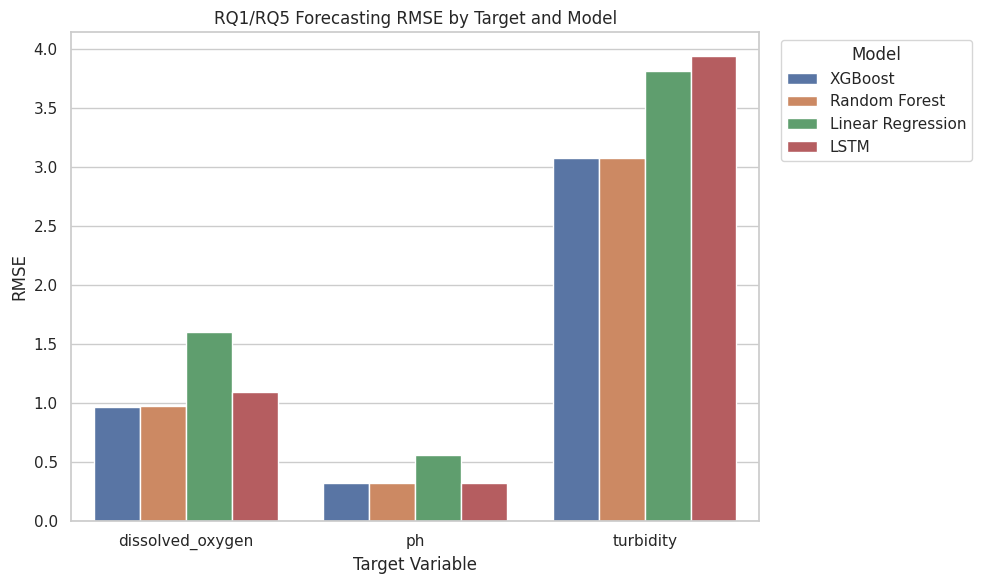

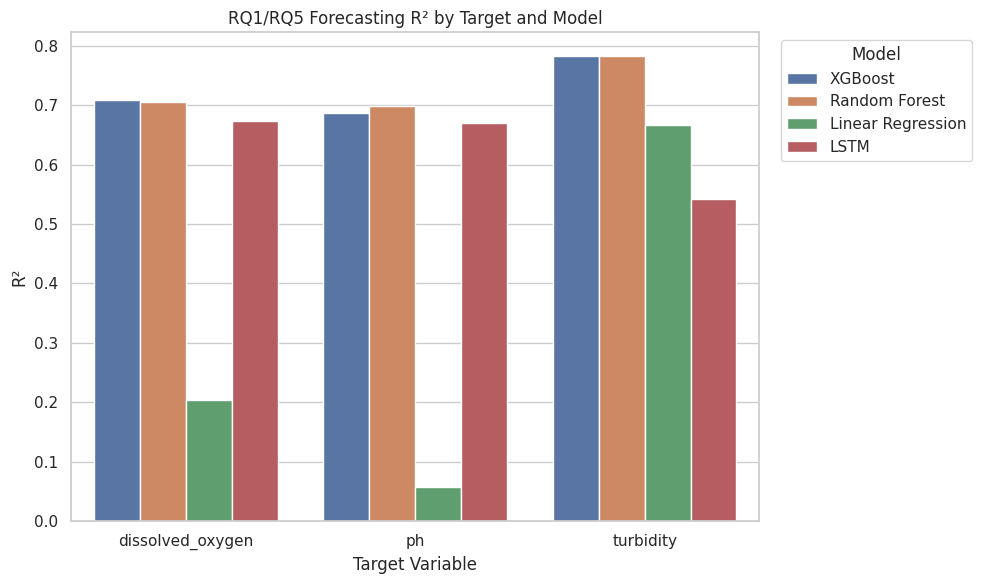

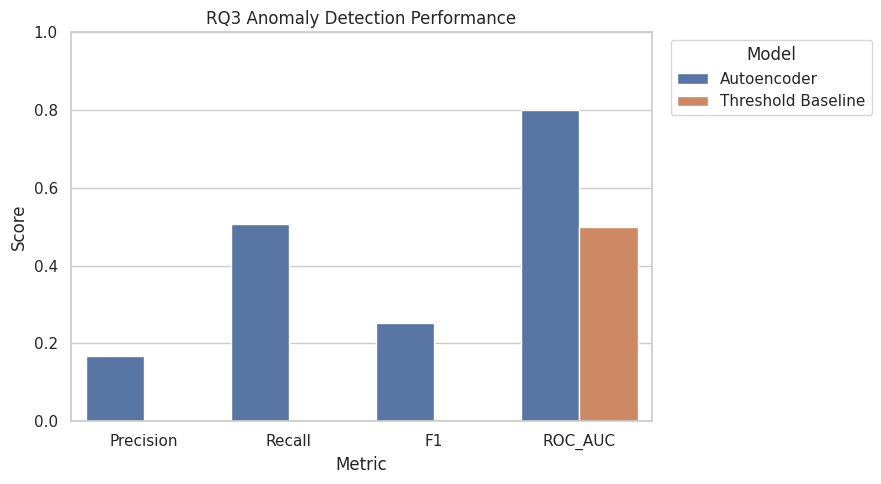

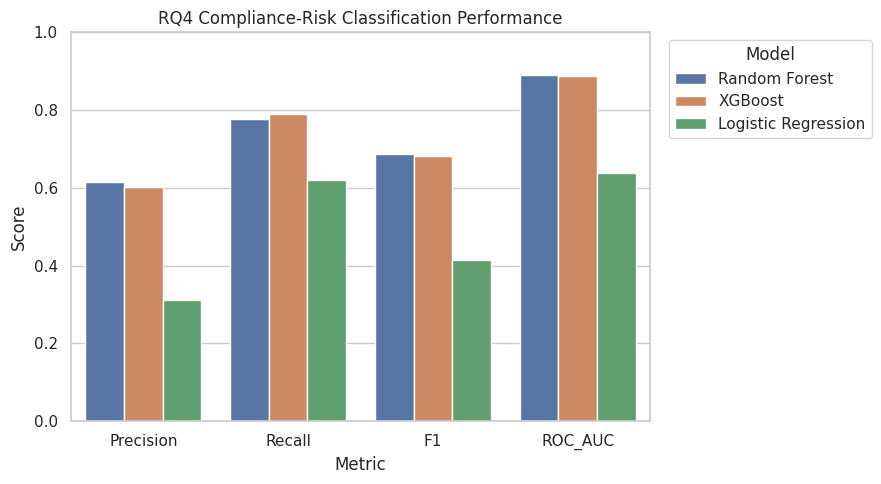

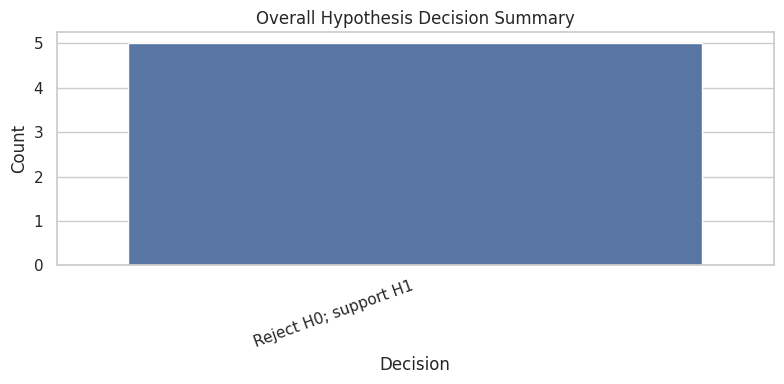

Paper-ready tables and figures exported.


In [54]:
# ============================================================
# exports for final selected model set
# ============================================================
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

# Save selected result tables.
selected_tables = {
    "rq1_forecasting_results_selected_models.csv": globals().get("rq1_results_df"),
    "rq1_lstm_results.csv": globals().get("rq1_lstm_results_df"),
    "rq2_driver_results.csv": globals().get("rq2_results_df"),
    "rq3_anomaly_results.csv": globals().get("rq3_results_df"),
    "rq4_classification_results.csv": globals().get("rq4_results_df"),
    "rq5_model_comparison.csv": globals().get("rq5_compare"),
    "hypothesis_decision_summary.csv": globals().get("hypothesis_decision_summary_df")
}

for filename, df_obj in selected_tables.items():
    if isinstance(df_obj, pd.DataFrame) and len(df_obj) > 0:
        df_obj.to_csv(f"outputs/tables/{filename}", index=False)
        print(f"Saved: outputs/tables/{filename}")

# Combined forecasting table for selected models.
forecast_parts = []
if isinstance(globals().get("rq1_results_df"), pd.DataFrame):
    forecast_parts.append(rq1_results_df)
if isinstance(globals().get("rq1_lstm_results_df"), pd.DataFrame):
    forecast_parts.append(rq1_lstm_results_df)
if forecast_parts:
    selected_forecast_df = pd.concat(forecast_parts, ignore_index=True)
    selected_forecast_df = selected_forecast_df[selected_forecast_df["model"].isin(["Linear Regression", "Random Forest", "XGBoost", "LSTM"])]
    selected_forecast_df.to_csv("outputs/tables/selected_forecasting_models_combined.csv", index=False)
    display(selected_forecast_df.sort_values(["target", "RMSE"]))

    # RMSE by target and model.
    plt.figure(figsize=(10, 6))
    sns.barplot(data=selected_forecast_df, x="target", y="RMSE", hue="model")
    plt.title("RQ1/RQ5 Forecasting RMSE by Target and Model")
    plt.xlabel("Target Variable")
    plt.ylabel("RMSE")
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("outputs/figures/rq1_rq5_rmse_by_target_model.png", dpi=300, bbox_inches="tight")
    plt.show()

    # R2 by target and model.
    plt.figure(figsize=(10, 6))
    sns.barplot(data=selected_forecast_df, x="target", y="R2", hue="model")
    plt.title("RQ1/RQ5 Forecasting R² by Target and Model")
    plt.xlabel("Target Variable")
    plt.ylabel("R²")
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("outputs/figures/rq1_rq5_r2_by_target_model.png", dpi=300, bbox_inches="tight")
    plt.show()

# RQ3 anomaly performance plot.
if isinstance(globals().get("rq3_results_df"), pd.DataFrame) and len(rq3_results_df) > 0:
    rq3_plot_df = rq3_results_df.melt(id_vars=["RQ", "model"], value_vars=["Precision", "Recall", "F1", "ROC_AUC"], var_name="Metric", value_name="Score")
    plt.figure(figsize=(9, 5))
    sns.barplot(data=rq3_plot_df, x="Metric", y="Score", hue="model")
    plt.title("RQ3 Anomaly Detection Performance")
    plt.ylim(0, 1)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("outputs/figures/rq3_anomaly_performance.png", dpi=300, bbox_inches="tight")
    plt.show()

# RQ4 classification performance plot.
if isinstance(globals().get("rq4_results_df"), pd.DataFrame) and len(rq4_results_df) > 0:
    rq4_plot_df = rq4_results_df.melt(id_vars=["RQ", "model"], value_vars=["Precision", "Recall", "F1", "ROC_AUC"], var_name="Metric", value_name="Score")
    plt.figure(figsize=(9, 5))
    sns.barplot(data=rq4_plot_df, x="Metric", y="Score", hue="model")
    plt.title("RQ4 Compliance-Risk Classification Performance")
    plt.ylim(0, 1)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("outputs/figures/rq4_classification_performance.png", dpi=300, bbox_inches="tight")
    plt.show()

# Hypothesis decision summary plot.
if isinstance(globals().get("hypothesis_decision_summary_df"), pd.DataFrame) and len(hypothesis_decision_summary_df) > 0:
    decision_counts = hypothesis_decision_summary_df["Overall Decision"].value_counts().reset_index()
    decision_counts.columns = ["Decision", "Count"]
    plt.figure(figsize=(8, 4))
    sns.barplot(data=decision_counts, x="Decision", y="Count")
    plt.title("Overall Hypothesis Decision Summary")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig("outputs/figures/hypothesis_decision_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

print("Paper-ready tables and figures exported.")


### Interpretation Guidance for the Final Report

Use the generated `hypothesis_decision_summary_df` as the formal decision table in the final report. A hypothesis is considered fully supported only when both criteria are met: (1) statistical significance at α = 0.05 and (2) the project-defined practical threshold. If only statistical significance is met, report this as partial support rather than full acceptance. If the p-value is not significant, report that the study failed to reject the null hypothesis for that comparison.

For RQ1 and RQ5, the strongest evidence comes from paired comparisons where models share the same test rows. Comparisons involving LSTM may be labeled as independent fallback tests when sequence test rows do not align one-to-one with tabular test rows. This distinction should be stated transparently in the Methods and Limitations sections.

NOTE: The RQ5 model-comparison section now retains only the selected forecasting models: Linear Regression, Random Forest, XGBoost, and LSTM. Linear Regression serves as the statistical baseline, Random Forest and XGBoost serve as nonlinear machine-learning challengers, and LSTM serves as the selected deep-learning sequence model. The comparison evaluates whether advanced ML/DL models reduce RMSE relative to the Linear Regression baseline and whether observed improvements are statistically significant using prediction-level error vectors. Results should be interpreted by target variable because turbidity, pH, and dissolved oxygen exhibit different temporal and nonlinear behavior.

#### Preliminary Findings by Research Question

- **RQ1 — Prediction.** Forecasting was completed for turbidity, pH, and dissolved oxygen using Linear Regression, Random Forest, XGBoost, and LSTM. XGBoost is evaluated as the primary nonlinear tabular model, while LSTM is evaluated as the selected deep-learning sequence model.

- **RQ2 — Driver Analysis.** Random Forest and XGBoost are used to identify important predictors through feature importance and SHAP analysis. Multiple regression provides statistical significance testing for linear effects.

- **RQ3 — Anomaly Detection.** Autoencoder-based anomaly detection is evaluated against a simple rule-based threshold baseline. The Autoencoder threshold is tuned using validation-set reconstruction error to improve F1-score.

- **RQ4 — Compliance Classification.** Logistic Regression is used as the interpretable baseline, while Random Forest and XGBoost are used as nonlinear machine-learning classifiers.

- **RQ5 — Model Comparison.** Linear Regression serves as the statistical baseline. Random Forest, XGBoost, and LSTM are compared against this baseline using prediction-level error vectors and formal paired or fallback statistical tests.


#### Interim Limitations and Risks

Several limitations remain at the interim stage. Hydrologic variables contain substantial missingness because not all WQP sites have corresponding USGS enrichment data. Lag and rolling-window features also introduce structural missingness, while some water-quality variables contain extreme or chemically implausible values requiring careful preprocessing.

Anomaly detection remains limited by class imbalance and weak anomaly labels. The compliance-risk target is also a surrogate operational-risk flag rather than a formal regulatory violation label.
Next Steps (for Final Report)

Below are some next steps for making further progress in the project.
- Finalize preprocessing, imputation, and outlier-handling decisions.
- Tune Linear Regression, Random Forest, XGBoost, Logistic Regression, LSTM, and Autoencoder models.
- Conduct SHAP-based explainability analysis for RQ2.
- Perform statistical significance testing for RQ1 and RQ5.
- Improve anomaly labeling and threshold calibration for RQ3.
- Complete final validation, model comparison, and paper-ready visualizations.
Please note, we will add to this section as the project data analysis and modelling progresses further.
